# **Importing libraries**

In [ ]:
import torch
import numpy
import random
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
import copy
from collections import defaultdict
import pandas as pd

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score
)

import torchvision.models as models
import torch.nn as nn
import torch.optim as optim

# **Load datasets**

In [ ]:
data_transforms = {
    "train": transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
]),
  "train_aug": transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
]),
  "val": transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
]),
}

# Load the dataset

train_dataset = datasets.OxfordIIITPet(
    root="./data", split="trainval", target_types="category",
    transform=data_transforms["train"], download=True
)

train_aug_dataset = datasets.OxfordIIITPet(
    root="./data", split="trainval", target_types="category",
    transform=data_transforms["train_aug"], download=True
)

val_dataset = datasets.OxfordIIITPet(
    root="./data", split="trainval", target_types="category",
    transform=data_transforms["val"], download=True
)

test_dataset = datasets.OxfordIIITPet(
    root="./data", split="test", target_types="category",
    transform=data_transforms["val"], download=True,
)

indices   = torch.randperm(len(train_dataset), generator=torch.Generator().manual_seed(42)).tolist()
val_size  = int(0.15 * len(train_dataset))

train_dataset = torch.utils.data.Subset(train_dataset, indices[val_size:])
train_aug_dataset = torch.utils.data.Subset(train_aug_dataset, indices[val_size:])
val_dataset   = torch.utils.data.Subset(val_dataset, indices[:val_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

# Binary datasets
binary_train_dataset = datasets.OxfordIIITPet(
    root="./data", split="trainval", target_types="binary-category",
    transform=data_transforms["train"], download=True
)
binary_val_dataset = datasets.OxfordIIITPet(
    root="./data", split="trainval", target_types="binary-category",
    transform=data_transforms["val"], download=True
)
binary_test_dataset = datasets.OxfordIIITPet(
    root="./data", split="test", target_types="binary-category",
    transform=data_transforms["val"], download=True
)

binary_train_dataset = torch.utils.data.Subset(binary_train_dataset, indices[val_size:])
binary_val_dataset   = torch.utils.data.Subset(binary_val_dataset, indices[:val_size])

binary_train_loader = DataLoader(binary_train_dataset, batch_size=64, shuffle=True,  num_workers=2, pin_memory=True)
binary_val_loader   = DataLoader(binary_val_dataset,   batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
binary_test_loader  = DataLoader(binary_test_dataset,  batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device} device")
print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

100%|██████████| 792M/792M [00:43<00:00, 18.0MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 10.1MB/s]


Using cuda device
Train: 3128 | Val: 552 | Test: 3669


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9831933..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5356624..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..1.541961].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0322802..2.622571].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4482791].


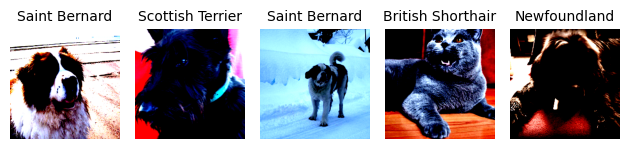

In [ ]:
#Teos block
nr_images = 5
fig, ax = plt.subplots(1, nr_images)
for i in range(nr_images):
  img, label = train_dataset[i]

  ax[i].imshow(img.permute(1, 2, 0))
  ax[i].set_title(test_dataset.classes[label], fontsize=10)
  ax[i].axis("off")
plt.tight_layout()
plt.show()

# **Training and evaluating model**

In [ ]:
def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=20, desc=""):
    model = model.to(device)
    best_weights = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(num_epochs):
        model.train()
        train_loss = train_correct = 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * inputs.size(0)
            train_correct += (outputs.argmax(1) == labels).sum().item()

        model.eval()
        val_loss = val_correct = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()

        train_loss /= len(train_loader.dataset)
        train_acc = train_correct / len(train_loader.dataset)
        val_loss /= len(val_loader.dataset)
        val_acc = val_correct / len(val_loader.dataset)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())

        print(f"[{desc}] Epoch {epoch+1}/{num_epochs}, train acc {train_acc:.4f}, val acc {val_acc:.4f}")

    model.load_state_dict(best_weights)
    return model, history


def evaluate(model, loader):
    model.eval().to(device)
    correct = total = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            correct += (model(inputs).argmax(1) == labels).sum().item()
            total   += labels.size(0)
    return correct / total


def plot_history(history, title=""):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    epochs = range(1, len(history["train_loss"]) + 1)
    ax1.plot(epochs, history["train_loss"], label="Train")
    ax1.plot(epochs, history["val_loss"],   label="Val")
    ax1.set_title(f"{title} — Loss"); ax1.legend(); ax1.set_xlabel("Epoch")
    ax2.plot(epochs, history["train_acc"], label="Train")
    ax2.plot(epochs, history["val_acc"],   label="Val")
    ax2.set_title(f"{title} — Accuracy"); ax2.legend(); ax2.set_xlabel("Epoch")
    plt.tight_layout()
    plt.show()


def train_model_gradual_unfreeze(model, train_loader, val_loader, criterion, optimizer, num_epochs=20):
    model = model.to(device)
    best_weights = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    # Unfreeze schedule: at which epoch to unfreeze which layer
    unfreeze_schedule = {5: model.layer4, 10: model.layer3, 15: model.layer2}

    for epoch in range(num_epochs):
        if epoch in unfreeze_schedule:
            layer = unfreeze_schedule[epoch]
            for param in layer.parameters():
                param.requires_grad = True
            optimizer.add_param_group({"params": layer.parameters(), "lr": optimizer.param_groups[0]["lr"]})
            print(f"Epoch {epoch+1}: unfroze {[k for k,v in unfreeze_schedule.items() if v is layer][0]}")

        model.train()
        train_loss = train_correct = 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * inputs.size(0)
            train_correct += (outputs.argmax(1) == labels).sum().item()

        model.eval()
        val_loss = val_correct = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()

        train_loss /= len(train_loader.dataset)
        train_acc = train_correct / len(train_loader.dataset)
        val_loss /= len(val_loader.dataset)
        val_acc = val_correct / len(val_loader.dataset)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())

        print(f"[GradUnfreeze] Epoch {epoch+1}/{num_epochs}, train acc {train_acc:.4f}, val acc {val_acc:.4f}")
    model.load_state_dict(best_weights)
    return model, history

[Binary] Epoch 1/20, train acc 0.8456, val acc 0.9457
[Binary] Epoch 2/20, train acc 0.9658, val acc 0.9764
[Binary] Epoch 3/20, train acc 0.9757, val acc 0.9783
[Binary] Epoch 4/20, train acc 0.9776, val acc 0.9801
[Binary] Epoch 5/20, train acc 0.9837, val acc 0.9819
[Binary] Epoch 6/20, train acc 0.9821, val acc 0.9819
[Binary] Epoch 7/20, train acc 0.9879, val acc 0.9819
[Binary] Epoch 8/20, train acc 0.9815, val acc 0.9837
[Binary] Epoch 9/20, train acc 0.9856, val acc 0.9819
[Binary] Epoch 10/20, train acc 0.9837, val acc 0.9873
[Binary] Epoch 11/20, train acc 0.9885, val acc 0.9837
[Binary] Epoch 12/20, train acc 0.9847, val acc 0.9855
[Binary] Epoch 13/20, train acc 0.9863, val acc 0.9837
[Binary] Epoch 14/20, train acc 0.9930, val acc 0.9837
[Binary] Epoch 15/20, train acc 0.9898, val acc 0.9837
[Binary] Epoch 16/20, train acc 0.9914, val acc 0.9855
[Binary] Epoch 17/20, train acc 0.9866, val acc 0.9819
[Binary] Epoch 18/20, train acc 0.9926, val acc 0.9873
[Binary] Epoch 19/2

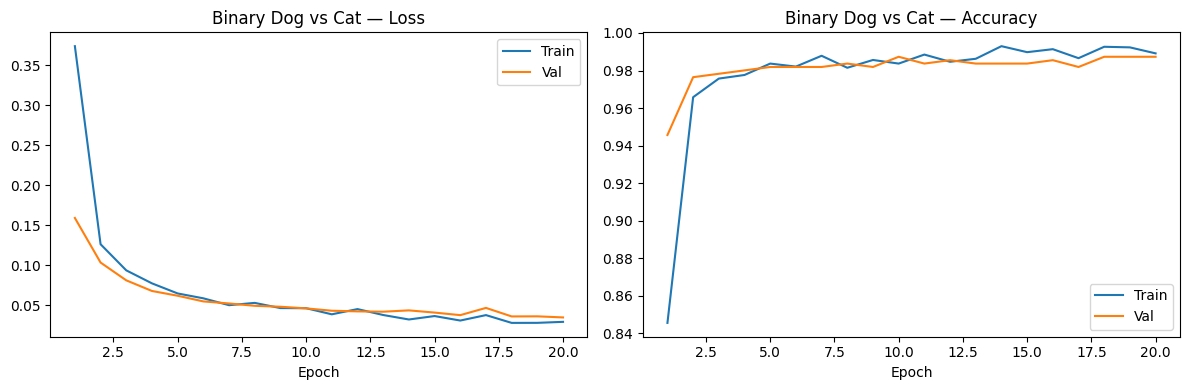

Binary test accuracy: 98.45%


In [ ]:
# BINARY CLASSIFICATION
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

model, history = train_model(model, binary_train_loader, binary_val_loader,
                              criterion, optimizer, num_epochs=20, desc="Binary")

plot_history(history, "Binary Dog vs Cat")

test_acc = evaluate(model, binary_test_loader)
print(f"Binary test accuracy: {test_acc*100:.2f}%")

[LinearProbe] Epoch 1/20, train acc 0.4895, val acc 0.7935
[LinearProbe] Epoch 2/20, train acc 0.8533, val acc 0.8659
[LinearProbe] Epoch 3/20, train acc 0.8967, val acc 0.8714
[LinearProbe] Epoch 4/20, train acc 0.9124, val acc 0.8986
[LinearProbe] Epoch 5/20, train acc 0.9284, val acc 0.9022
[LinearProbe] Epoch 6/20, train acc 0.9338, val acc 0.8931
[LinearProbe] Epoch 7/20, train acc 0.9399, val acc 0.8967
[LinearProbe] Epoch 8/20, train acc 0.9492, val acc 0.9022
[LinearProbe] Epoch 9/20, train acc 0.9568, val acc 0.8949
[LinearProbe] Epoch 10/20, train acc 0.9594, val acc 0.9022
[LinearProbe] Epoch 11/20, train acc 0.9648, val acc 0.8913
[LinearProbe] Epoch 12/20, train acc 0.9728, val acc 0.8913
[LinearProbe] Epoch 13/20, train acc 0.9731, val acc 0.8931
[LinearProbe] Epoch 14/20, train acc 0.9725, val acc 0.9004
[LinearProbe] Epoch 15/20, train acc 0.9754, val acc 0.9004
[LinearProbe] Epoch 16/20, train acc 0.9824, val acc 0.9022
[LinearProbe] Epoch 17/20, train acc 0.9792, val 

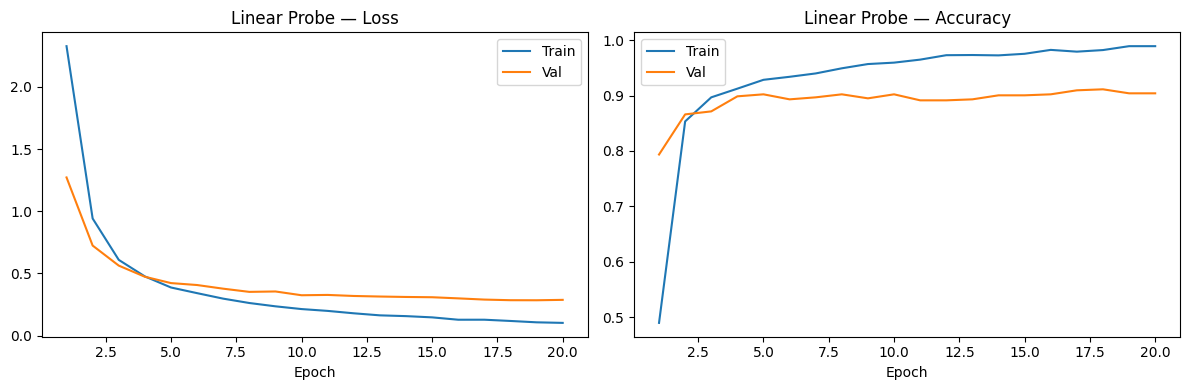

Linear probe test accuracy: 88.88%


In [ ]:
#LINEAR PROBING

model_lp = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Freezing the layers
for param in model_lp.parameters():
    param.requires_grad = False

model_lp.fc = nn.Linear(model_lp.fc.in_features, 37)

# cross entropy loss and Adam optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_lp.fc.parameters(), lr=0.001)

model_lp, history_lp = train_model(model_lp, train_loader, val_loader,
                                    criterion, optimizer, num_epochs=20, desc="LinearProbe")

plot_history(history_lp, "Linear Probe")

probe_test_acc = evaluate(model_lp, test_loader)
print(f"Linear probe test accuracy: {probe_test_acc*100:.2f}%")

# **Strategy 1**

# l=1

[FT l=1] Epoch 1/20, train acc 0.5486, val acc 0.8333
[FT l=1] Epoch 2/20, train acc 0.9140, val acc 0.8678
[FT l=1] Epoch 3/20, train acc 0.9626, val acc 0.8986
[FT l=1] Epoch 4/20, train acc 0.9904, val acc 0.9094
[FT l=1] Epoch 5/20, train acc 0.9997, val acc 0.9040
[FT l=1] Epoch 6/20, train acc 1.0000, val acc 0.9040
[FT l=1] Epoch 7/20, train acc 1.0000, val acc 0.9022
[FT l=1] Epoch 8/20, train acc 1.0000, val acc 0.9040
[FT l=1] Epoch 9/20, train acc 1.0000, val acc 0.9022
[FT l=1] Epoch 10/20, train acc 1.0000, val acc 0.9004
[FT l=1] Epoch 11/20, train acc 1.0000, val acc 0.9022
[FT l=1] Epoch 12/20, train acc 1.0000, val acc 0.9022
[FT l=1] Epoch 13/20, train acc 1.0000, val acc 0.9022
[FT l=1] Epoch 14/20, train acc 1.0000, val acc 0.8986
[FT l=1] Epoch 15/20, train acc 1.0000, val acc 0.9022
[FT l=1] Epoch 16/20, train acc 1.0000, val acc 0.9004
[FT l=1] Epoch 17/20, train acc 1.0000, val acc 0.9022
[FT l=1] Epoch 18/20, train acc 1.0000, val acc 0.8986
[FT l=1] Epoch 19/2

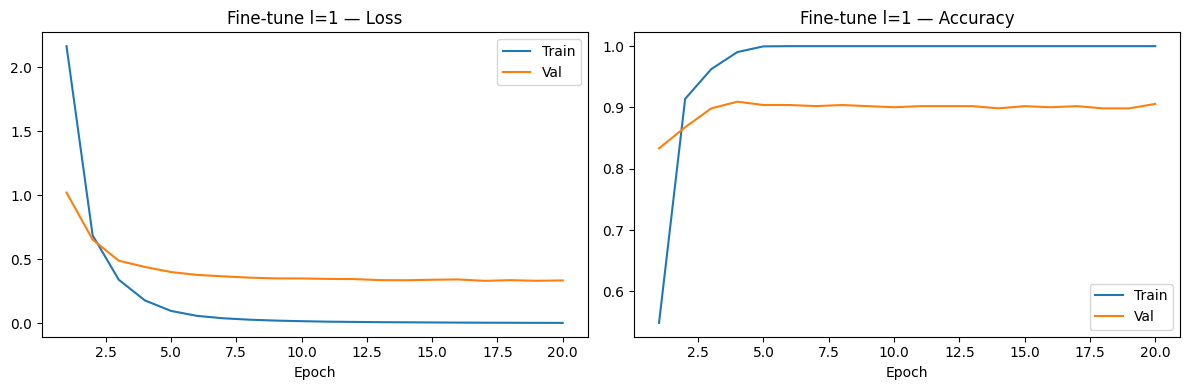

Fine-tune l=1 test accuracy: 88.42%
Improvement over linear probe: -0.46%


In [ ]:
# FINE-TUNING STRATEGY 1 — l=1 (unfreeze layer4 + fc)
model_ft1 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for param in model_ft1.parameters():
    param.requires_grad = False

for param in model_ft1.layer4.parameters():
    param.requires_grad = True

model_ft1.fc = nn.Linear(model_ft1.fc.in_features, 37)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model_ft1.parameters()), lr=1e-4)

model_ft1, history_ft1 = train_model(model_ft1, train_loader, val_loader,
                                      criterion, optimizer, num_epochs=20, desc="FT l=1")

plot_history(history_ft1, "Fine-tune l=1")

ft1_test_acc = evaluate(model_ft1, test_loader)
print(f"Fine-tune l=1 test accuracy: {ft1_test_acc*100:.2f}%")
print(f"Improvement over linear probe: {(ft1_test_acc - probe_test_acc)*100:.2f}%")

# l=2

[FT l=2] Epoch 1/20, train acc 0.3891, val acc 0.7391
[FT l=2] Epoch 2/20, train acc 0.8625, val acc 0.8533
[FT l=2] Epoch 3/20, train acc 0.9383, val acc 0.8877
[FT l=2] Epoch 4/20, train acc 0.9706, val acc 0.9076
[FT l=2] Epoch 5/20, train acc 0.9914, val acc 0.9130
[FT l=2] Epoch 6/20, train acc 0.9968, val acc 0.9203
[FT l=2] Epoch 7/20, train acc 0.9994, val acc 0.9149
[FT l=2] Epoch 8/20, train acc 1.0000, val acc 0.9221
[FT l=2] Epoch 9/20, train acc 1.0000, val acc 0.9221
[FT l=2] Epoch 10/20, train acc 1.0000, val acc 0.9203
[FT l=2] Epoch 11/20, train acc 1.0000, val acc 0.9275
[FT l=2] Epoch 12/20, train acc 1.0000, val acc 0.9257
[FT l=2] Epoch 13/20, train acc 1.0000, val acc 0.9221
[FT l=2] Epoch 14/20, train acc 1.0000, val acc 0.9293
[FT l=2] Epoch 15/20, train acc 1.0000, val acc 0.9275
[FT l=2] Epoch 16/20, train acc 1.0000, val acc 0.9293
[FT l=2] Epoch 17/20, train acc 1.0000, val acc 0.9275
[FT l=2] Epoch 18/20, train acc 1.0000, val acc 0.9239
[FT l=2] Epoch 19/2

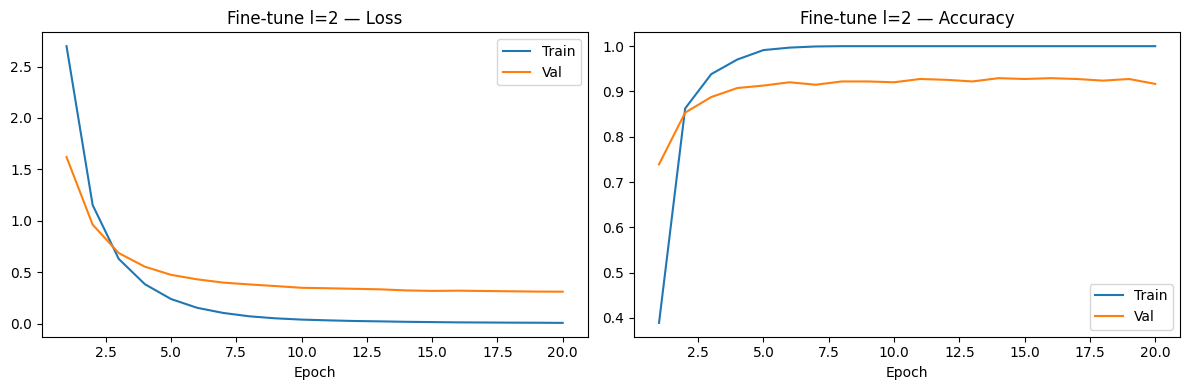

Fine-tune l=2 test accuracy: 88.66%
Improvement over linear probe: -0.22%


In [ ]:
# FINE-TUNING STRATEGY 1 — l=2 (unfreeze layer4 + layer3 + fc)
model_ft2 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for param in model_ft2.parameters():
    param.requires_grad = False

for param in model_ft2.layer4.parameters():
    param.requires_grad = True
for param in model_ft2.layer3.parameters():
    param.requires_grad = True

model_ft2.fc = nn.Linear(model_ft2.fc.in_features, 37)

# cross entropy loss and Adam optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model_ft2.parameters()), lr=5e-5)

model_ft2, history_ft2 = train_model(model_ft2, train_loader, val_loader,
                                      criterion, optimizer, num_epochs=20, desc="FT l=2")

plot_history(history_ft2, "Fine-tune l=2")

ft2_test_acc = evaluate(model_ft2, test_loader)
print(f"Fine-tune l=2 test accuracy: {ft2_test_acc*100:.2f}%")
print(f"Improvement over linear probe: {(ft2_test_acc - probe_test_acc)*100:.2f}%")

# l=3

[FT l=3] Epoch 1/20, train acc 0.3999, val acc 0.7264
[FT l=3] Epoch 2/20, train acc 0.8686, val acc 0.8406
[FT l=3] Epoch 3/20, train acc 0.9412, val acc 0.8804
[FT l=3] Epoch 4/20, train acc 0.9719, val acc 0.8895
[FT l=3] Epoch 5/20, train acc 0.9920, val acc 0.9022
[FT l=3] Epoch 6/20, train acc 0.9968, val acc 0.9058
[FT l=3] Epoch 7/20, train acc 0.9994, val acc 0.9130
[FT l=3] Epoch 8/20, train acc 0.9997, val acc 0.9112
[FT l=3] Epoch 9/20, train acc 1.0000, val acc 0.9167
[FT l=3] Epoch 10/20, train acc 1.0000, val acc 0.9112
[FT l=3] Epoch 11/20, train acc 1.0000, val acc 0.9239
[FT l=3] Epoch 12/20, train acc 1.0000, val acc 0.9203
[FT l=3] Epoch 13/20, train acc 1.0000, val acc 0.9221
[FT l=3] Epoch 14/20, train acc 1.0000, val acc 0.9221
[FT l=3] Epoch 15/20, train acc 1.0000, val acc 0.9185
[FT l=3] Epoch 16/20, train acc 1.0000, val acc 0.9221
[FT l=3] Epoch 17/20, train acc 1.0000, val acc 0.9221
[FT l=3] Epoch 18/20, train acc 1.0000, val acc 0.9203
[FT l=3] Epoch 19/2

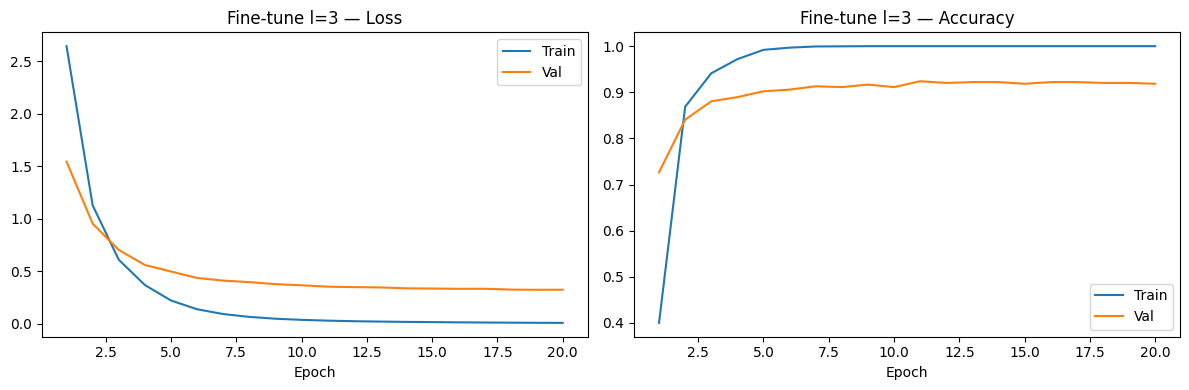

Fine-tune l=3 test accuracy: 89.04%
Improvement over linear probe: 0.16%


In [ ]:
# FINE-TUNING STRATEGY 1 — l=3 (unfreeze layer4 + layer3 + layer 2 + fc)
model_ft3 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for param in model_ft3.parameters():
    param.requires_grad = False

for param in model_ft3.layer4.parameters():
    param.requires_grad = True
for param in model_ft3.layer3.parameters():
    param.requires_grad = True
for param in model_ft3.layer2.parameters():
    param.requires_grad = True

model_ft3.fc = nn.Linear(model_ft3.fc.in_features, 37)

# cross entropy loss and Adam optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model_ft3.parameters()), lr=5e-5)

model_ft3, history_ft3 = train_model(model_ft3, train_loader, val_loader,
                                      criterion, optimizer, num_epochs=20, desc="FT l=3")

plot_history(history_ft3, "Fine-tune l=3")

ft3_test_acc = evaluate(model_ft3, test_loader)
print(f"Fine-tune l=3 test accuracy: {ft3_test_acc*100:.2f}%")
print(f"Improvement over linear probe: {(ft3_test_acc - probe_test_acc)*100:.2f}%")

# l=4

[FT l=4] Epoch 1/20, train acc 0.4102, val acc 0.7174
[FT l=4] Epoch 2/20, train acc 0.8830, val acc 0.8696
[FT l=4] Epoch 3/20, train acc 0.9479, val acc 0.8967
[FT l=4] Epoch 4/20, train acc 0.9767, val acc 0.8913
[FT l=4] Epoch 5/20, train acc 0.9910, val acc 0.8986
[FT l=4] Epoch 6/20, train acc 0.9965, val acc 0.9076
[FT l=4] Epoch 7/20, train acc 0.9990, val acc 0.9076
[FT l=4] Epoch 8/20, train acc 1.0000, val acc 0.9185
[FT l=4] Epoch 9/20, train acc 1.0000, val acc 0.9167
[FT l=4] Epoch 10/20, train acc 1.0000, val acc 0.9149
[FT l=4] Epoch 11/20, train acc 1.0000, val acc 0.9149
[FT l=4] Epoch 12/20, train acc 1.0000, val acc 0.9167
[FT l=4] Epoch 13/20, train acc 1.0000, val acc 0.9167
[FT l=4] Epoch 14/20, train acc 1.0000, val acc 0.9167
[FT l=4] Epoch 15/20, train acc 1.0000, val acc 0.9149
[FT l=4] Epoch 16/20, train acc 1.0000, val acc 0.9112
[FT l=4] Epoch 17/20, train acc 1.0000, val acc 0.9167
[FT l=4] Epoch 18/20, train acc 1.0000, val acc 0.9130
[FT l=4] Epoch 19/2

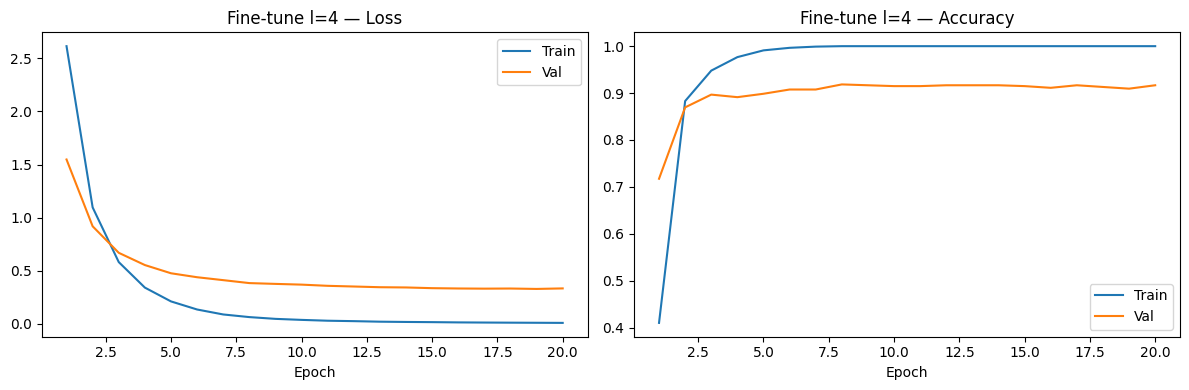

Fine-tune l=4 test accuracy: 88.61%
Improvement over linear probe: -0.27%


In [ ]:
# FINE-TUNING STRATEGY 1 — l=4 (unfreeze layer4 + layer3 + layer2 + layer1 + fc)
model_ft4 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for param in model_ft4.parameters():
    param.requires_grad = False

for param in model_ft4.layer4.parameters():
    param.requires_grad = True
for param in model_ft4.layer3.parameters():
    param.requires_grad = True
for param in model_ft4.layer2.parameters():
    param.requires_grad = True
for param in model_ft4.layer1.parameters():
    param.requires_grad = True

model_ft4.fc = nn.Linear(model_ft4.fc.in_features, 37)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model_ft4.parameters()), lr=5e-5)


model_ft4, history_ft4 = train_model(model_ft4, train_loader, val_loader,
                                      criterion, optimizer, num_epochs=20, desc="FT l=4")

plot_history(history_ft4, "Fine-tune l=4")

ft4_test_acc = evaluate(model_ft4, test_loader)
print(f"Fine-tune l=4 test accuracy: {ft4_test_acc*100:.2f}%")
print(f"Improvement over linear probe: {(ft4_test_acc - probe_test_acc)*100:.2f}%")

# **Strategy 2**

[GradUnfreeze] Epoch 1/20, train acc 0.0719, val acc 0.1214
[GradUnfreeze] Epoch 2/20, train acc 0.2343, val acc 0.3297
[GradUnfreeze] Epoch 3/20, train acc 0.4313, val acc 0.5054
[GradUnfreeze] Epoch 4/20, train acc 0.5726, val acc 0.6159
[GradUnfreeze] Epoch 5/20, train acc 0.6586, val acc 0.6830
Epoch 6: unfroze 5
[GradUnfreeze] Epoch 6/20, train acc 0.8203, val acc 0.8623
[GradUnfreeze] Epoch 7/20, train acc 0.9453, val acc 0.8986
[GradUnfreeze] Epoch 8/20, train acc 0.9879, val acc 0.9076
[GradUnfreeze] Epoch 9/20, train acc 0.9962, val acc 0.9094
[GradUnfreeze] Epoch 10/20, train acc 1.0000, val acc 0.9112
Epoch 11: unfroze 10
[GradUnfreeze] Epoch 11/20, train acc 1.0000, val acc 0.9058
[GradUnfreeze] Epoch 12/20, train acc 1.0000, val acc 0.9058
[GradUnfreeze] Epoch 13/20, train acc 1.0000, val acc 0.9130
[GradUnfreeze] Epoch 14/20, train acc 1.0000, val acc 0.9167
[GradUnfreeze] Epoch 15/20, train acc 1.0000, val acc 0.9185
Epoch 16: unfroze 15
[GradUnfreeze] Epoch 16/20, train

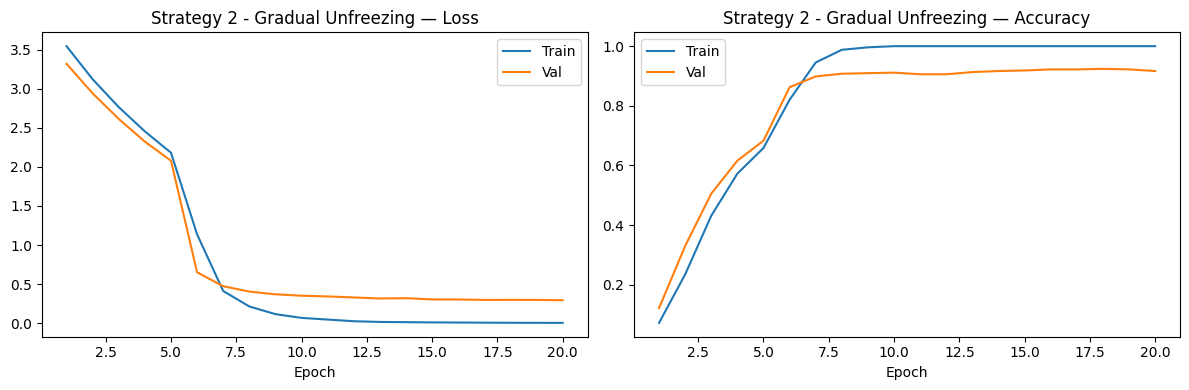

Strategy 2 test accuracy: 90.24%
Improvement over linear probe: 1.36%


In [ ]:
# Strageguy 2: GRADUAL UNFREEZING
model_s2 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for param in model_s2.parameters():
    param.requires_grad = False
model_s2.fc = nn.Linear(model_s2.fc.in_features, 37)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_s2.fc.parameters(), lr=1e-4)

model_s2, history_s2 = train_model_gradual_unfreeze(
    model_s2, train_loader, val_loader, criterion, optimizer, num_epochs=20
)
plot_history(history_s2, "Strategy 2 - Gradual Unfreezing")

s2_test_acc = evaluate(model_s2, test_loader)
print(f"Strategy 2 test accuracy: {s2_test_acc*100:.2f}%")
print(f"Improvement over linear probe: {(s2_test_acc - probe_test_acc)*100:.2f}%")

# **Less data**

In [ ]:
def run_tests(train_loader, val_loader, L2=0, advanced_eval = False, class_names = None, cat_labels = None, weighted_criterion=None):


    model_ft = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)


    # unfreez layers
    for param in model_ft.parameters():
        param.requires_grad = False

    for param in model_ft.layer4.parameters():
        param.requires_grad = True

    for param in model_ft.layer3.parameters():
        param.requires_grad = True

    for param in model_ft.layer2.parameters():
        param.requires_grad = True



    model_ft.fc = nn.Linear(model_ft.fc.in_features, 37)

    criterion = weighted_criterion if weighted_criterion else nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model_ft.parameters()), lr=5e-5, weight_decay=L2)


    model_ft, history_ft = train_model(model_ft, train_loader, val_loader,
                                        criterion, optimizer, num_epochs=20, desc="FT l=3")

    plot_history(history_ft, "Fine-tune l=3")

    # Evaluating
    if advanced_eval == True:
      evaluate_adv(model_ft, test_loader, class_names, cat_labels)

    else:
      ft_test_acc = evaluate(model_ft, test_loader)
      print(f"Fine-tune l=3 test accuracy: {ft_test_acc*100:.2f}%")
      #print(f"Improvement over linear probe: {(ft_test_acc - probe_test_acc)*100:.2f}%")

    # ---- Strategy 2 ------

    model_s2 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    for param in model_s2.parameters():
        param.requires_grad = False
    model_s2.fc = nn.Linear(model_s2.fc.in_features, 37)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model_s2.fc.parameters(), lr=1e-4)

    model_s2, history_s2 = train_model_gradual_unfreeze(
        model_s2, train_loader, val_loader, criterion, optimizer, num_epochs=20
    )
    plot_history(history_s2, "Strategy 2 - Gradual Unfreezing")

     # Evaluating
    if advanced_eval == True:
      evaluate_adv(model_s2, test_loader, class_names, cat_labels)
    else:
      s2_test_acc = evaluate(model_s2, test_loader)
      print(f"Strategy 2 test accuracy: {s2_test_acc*100:.2f}%")
      #print(f"Improvement over linear probe: {(s2_test_acc - probe_test_acc)*100:.2f}%")

In [ ]:
def stratify_traindata(train_dataset, fraction):
  # Group indices by class
  class_indices = defaultdict(list)

  for idx, (_, label) in enumerate(train_dataset):
      class_indices[label].append(idx)

  # Stratified subset indices
  subset_indices = []

  random.seed(42)

  for label, indices in class_indices.items():
      random.shuffle(indices)

      n_samples = max(1, int(len(indices) * fraction))
      subset_indices.extend(indices[:n_samples])

  stratified_subset = torch.utils.data.Subset(train_dataset, subset_indices)

  # DataLoader
  return DataLoader(stratified_subset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)

# **10% of the data**

[FT l=3] Epoch 1/20, train acc 0.0473, val acc 0.0942
[FT l=3] Epoch 2/20, train acc 0.2973, val acc 0.1721
[FT l=3] Epoch 3/20, train acc 0.5878, val acc 0.2736
[FT l=3] Epoch 4/20, train acc 0.8345, val acc 0.3732
[FT l=3] Epoch 5/20, train acc 0.9358, val acc 0.4511
[FT l=3] Epoch 6/20, train acc 0.9730, val acc 0.4946
[FT l=3] Epoch 7/20, train acc 0.9966, val acc 0.5543
[FT l=3] Epoch 8/20, train acc 0.9966, val acc 0.5761
[FT l=3] Epoch 9/20, train acc 0.9932, val acc 0.6014
[FT l=3] Epoch 10/20, train acc 1.0000, val acc 0.6159
[FT l=3] Epoch 11/20, train acc 1.0000, val acc 0.6413
[FT l=3] Epoch 12/20, train acc 1.0000, val acc 0.6522
[FT l=3] Epoch 13/20, train acc 1.0000, val acc 0.6612
[FT l=3] Epoch 14/20, train acc 1.0000, val acc 0.6649
[FT l=3] Epoch 15/20, train acc 1.0000, val acc 0.6757
[FT l=3] Epoch 16/20, train acc 1.0000, val acc 0.6757
[FT l=3] Epoch 17/20, train acc 1.0000, val acc 0.6739
[FT l=3] Epoch 18/20, train acc 1.0000, val acc 0.6775
[FT l=3] Epoch 19/2

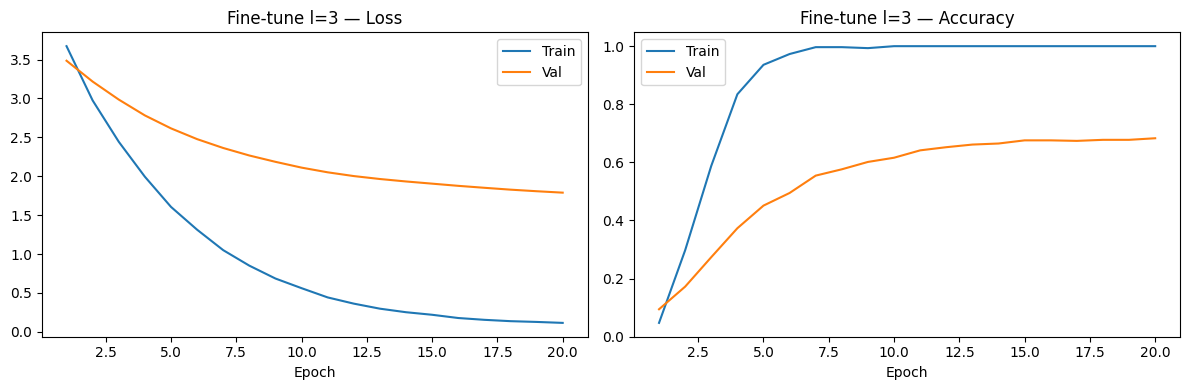

Fine-tune l=3 test accuracy: 65.25%
[GradUnfreeze] Epoch 1/20, train acc 0.0169, val acc 0.0236
[GradUnfreeze] Epoch 2/20, train acc 0.0338, val acc 0.0362
[GradUnfreeze] Epoch 3/20, train acc 0.0270, val acc 0.0507
[GradUnfreeze] Epoch 4/20, train acc 0.0372, val acc 0.0598
[GradUnfreeze] Epoch 5/20, train acc 0.0574, val acc 0.0743
Epoch 6: unfroze 5
[GradUnfreeze] Epoch 6/20, train acc 0.1385, val acc 0.2536
[GradUnfreeze] Epoch 7/20, train acc 0.7399, val acc 0.4112
[GradUnfreeze] Epoch 8/20, train acc 0.9426, val acc 0.5399
[GradUnfreeze] Epoch 9/20, train acc 0.9899, val acc 0.6159
[GradUnfreeze] Epoch 10/20, train acc 0.9966, val acc 0.6576
Epoch 11: unfroze 10
[GradUnfreeze] Epoch 11/20, train acc 1.0000, val acc 0.6793
[GradUnfreeze] Epoch 12/20, train acc 1.0000, val acc 0.6975
[GradUnfreeze] Epoch 13/20, train acc 1.0000, val acc 0.7138
[GradUnfreeze] Epoch 14/20, train acc 1.0000, val acc 0.7138
[GradUnfreeze] Epoch 15/20, train acc 1.0000, val acc 0.7192
Epoch 16: unfroze 

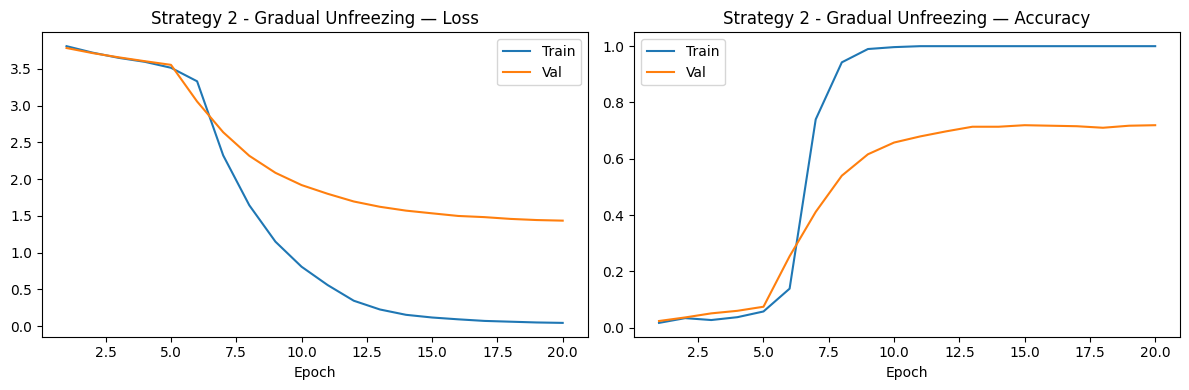

Strategy 2 test accuracy: 71.71%


In [ ]:
train_loader_stratified = stratify_traindata(train_dataset, 0.1)
run_tests(train_loader_stratified, val_loader)

## **1% of the data**

[FT l=3] Epoch 1/20, train acc 0.0000, val acc 0.0362
[FT l=3] Epoch 2/20, train acc 0.1622, val acc 0.0435
[FT l=3] Epoch 3/20, train acc 0.2973, val acc 0.0417
[FT l=3] Epoch 4/20, train acc 0.6486, val acc 0.0471
[FT l=3] Epoch 5/20, train acc 0.9189, val acc 0.0507
[FT l=3] Epoch 6/20, train acc 1.0000, val acc 0.0670
[FT l=3] Epoch 7/20, train acc 1.0000, val acc 0.0743
[FT l=3] Epoch 8/20, train acc 1.0000, val acc 0.0870
[FT l=3] Epoch 9/20, train acc 1.0000, val acc 0.0996
[FT l=3] Epoch 10/20, train acc 1.0000, val acc 0.1087
[FT l=3] Epoch 11/20, train acc 1.0000, val acc 0.1123
[FT l=3] Epoch 12/20, train acc 1.0000, val acc 0.1232
[FT l=3] Epoch 13/20, train acc 1.0000, val acc 0.1413
[FT l=3] Epoch 14/20, train acc 1.0000, val acc 0.1576
[FT l=3] Epoch 15/20, train acc 1.0000, val acc 0.1649
[FT l=3] Epoch 16/20, train acc 1.0000, val acc 0.1667
[FT l=3] Epoch 17/20, train acc 1.0000, val acc 0.1721
[FT l=3] Epoch 18/20, train acc 1.0000, val acc 0.1739
[FT l=3] Epoch 19/2

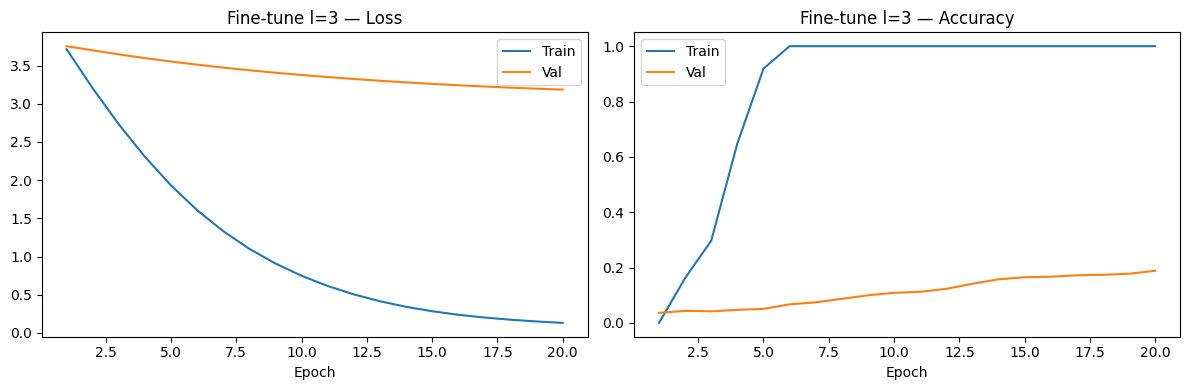

Fine-tune l=3 test accuracy: 20.63%
[GradUnfreeze] Epoch 1/20, train acc 0.0000, val acc 0.0308
[GradUnfreeze] Epoch 2/20, train acc 0.0000, val acc 0.0326
[GradUnfreeze] Epoch 3/20, train acc 0.0000, val acc 0.0362
[GradUnfreeze] Epoch 4/20, train acc 0.0000, val acc 0.0380
[GradUnfreeze] Epoch 5/20, train acc 0.0000, val acc 0.0435
Epoch 6: unfroze 5
[GradUnfreeze] Epoch 6/20, train acc 0.0000, val acc 0.0543
[GradUnfreeze] Epoch 7/20, train acc 0.2162, val acc 0.0761
[GradUnfreeze] Epoch 8/20, train acc 0.8108, val acc 0.1051
[GradUnfreeze] Epoch 9/20, train acc 0.9730, val acc 0.1304
[GradUnfreeze] Epoch 10/20, train acc 1.0000, val acc 0.1576
Epoch 11: unfroze 10
[GradUnfreeze] Epoch 11/20, train acc 1.0000, val acc 0.1866
[GradUnfreeze] Epoch 12/20, train acc 1.0000, val acc 0.2029
[GradUnfreeze] Epoch 13/20, train acc 1.0000, val acc 0.2174
[GradUnfreeze] Epoch 14/20, train acc 1.0000, val acc 0.2301
[GradUnfreeze] Epoch 15/20, train acc 1.0000, val acc 0.2464
Epoch 16: unfroze 

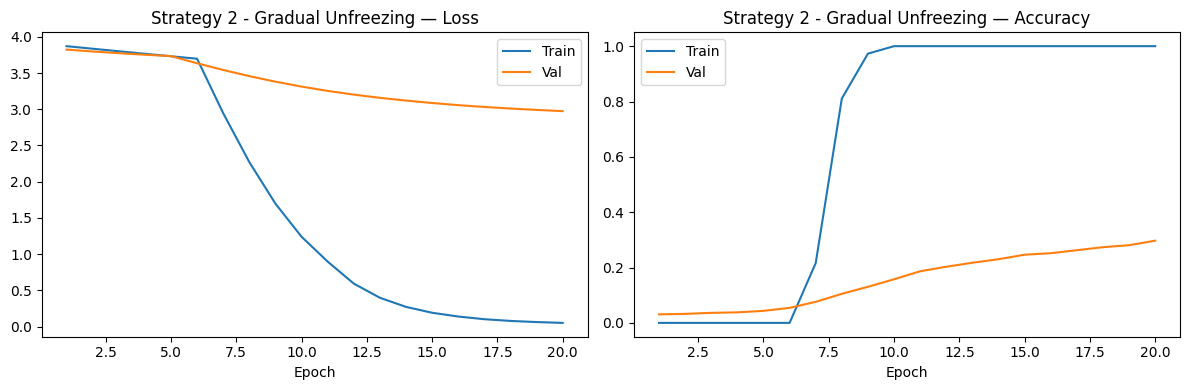

Strategy 2 test accuracy: 28.92%


In [ ]:
train_loader_stratified = stratify_traindata(train_dataset, 0.01)
run_tests(train_loader_stratified, val_loader)

# **Data augmentation**

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 177MB/s]


[FT l=3] Epoch 1/20, train acc 0.2925, val acc 0.6938
[FT l=3] Epoch 2/20, train acc 0.6656, val acc 0.8315
[FT l=3] Epoch 3/20, train acc 0.7484, val acc 0.8496
[FT l=3] Epoch 4/20, train acc 0.7855, val acc 0.8822
[FT l=3] Epoch 5/20, train acc 0.8034, val acc 0.8859
[FT l=3] Epoch 6/20, train acc 0.8328, val acc 0.8931
[FT l=3] Epoch 7/20, train acc 0.8357, val acc 0.9185
[FT l=3] Epoch 8/20, train acc 0.8555, val acc 0.9058
[FT l=3] Epoch 9/20, train acc 0.8590, val acc 0.9149
[FT l=3] Epoch 10/20, train acc 0.8708, val acc 0.9112
[FT l=3] Epoch 11/20, train acc 0.8728, val acc 0.9221
[FT l=3] Epoch 12/20, train acc 0.8792, val acc 0.9221
[FT l=3] Epoch 13/20, train acc 0.8919, val acc 0.9221
[FT l=3] Epoch 14/20, train acc 0.8951, val acc 0.9076
[FT l=3] Epoch 15/20, train acc 0.8865, val acc 0.9275
[FT l=3] Epoch 16/20, train acc 0.9060, val acc 0.9203
[FT l=3] Epoch 17/20, train acc 0.8983, val acc 0.9257
[FT l=3] Epoch 18/20, train acc 0.9140, val acc 0.9203
[FT l=3] Epoch 19/2

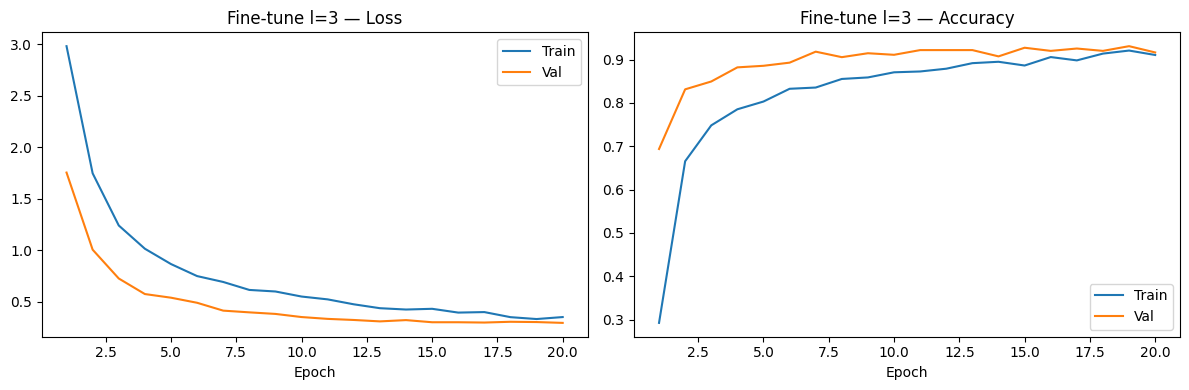

Fine-tune l=3 test accuracy: 89.59%
[GradUnfreeze] Epoch 1/20, train acc 0.0364, val acc 0.0725
[GradUnfreeze] Epoch 2/20, train acc 0.1113, val acc 0.1938
[GradUnfreeze] Epoch 3/20, train acc 0.2155, val acc 0.3261
[GradUnfreeze] Epoch 4/20, train acc 0.3328, val acc 0.4457
[GradUnfreeze] Epoch 5/20, train acc 0.4364, val acc 0.5417
Epoch 6: unfroze 5
[GradUnfreeze] Epoch 6/20, train acc 0.6535, val acc 0.8533
[GradUnfreeze] Epoch 7/20, train acc 0.7788, val acc 0.8714
[GradUnfreeze] Epoch 8/20, train acc 0.8050, val acc 0.9022
[GradUnfreeze] Epoch 9/20, train acc 0.8354, val acc 0.9130
[GradUnfreeze] Epoch 10/20, train acc 0.8469, val acc 0.9112
Epoch 11: unfroze 10
[GradUnfreeze] Epoch 11/20, train acc 0.8501, val acc 0.9058
[GradUnfreeze] Epoch 12/20, train acc 0.8622, val acc 0.8986
[GradUnfreeze] Epoch 13/20, train acc 0.8724, val acc 0.9094
[GradUnfreeze] Epoch 14/20, train acc 0.8862, val acc 0.9149
[GradUnfreeze] Epoch 15/20, train acc 0.8939, val acc 0.9149
Epoch 16: unfroze 

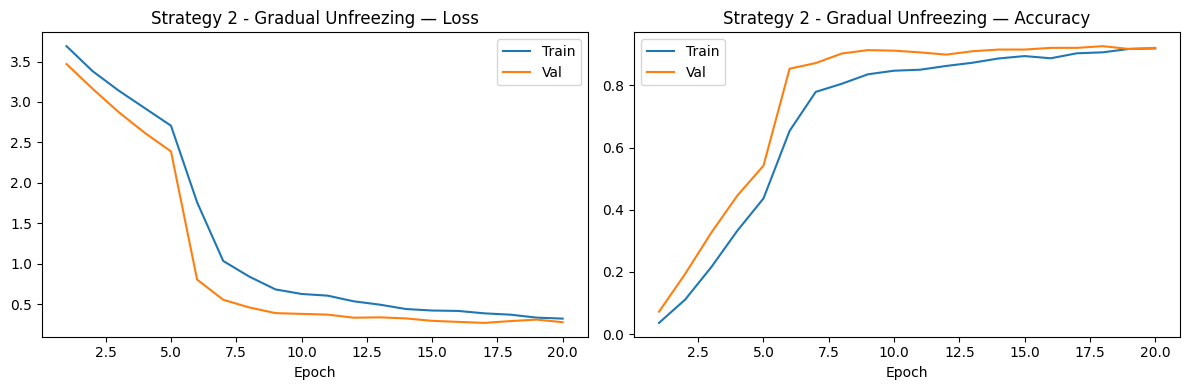

Strategy 2 test accuracy: 87.79%


In [ ]:
# 100%

train_aug_loader = DataLoader(train_aug_dataset, batch_size=64, shuffle=True,  num_workers=2, pin_memory=True)
run_tests(train_aug_loader, val_loader)

[FT l=3] Epoch 1/20, train acc 0.0304, val acc 0.0344
[FT l=3] Epoch 2/20, train acc 0.0709, val acc 0.0833
[FT l=3] Epoch 3/20, train acc 0.1791, val acc 0.1649
[FT l=3] Epoch 4/20, train acc 0.3243, val acc 0.2500
[FT l=3] Epoch 5/20, train acc 0.4392, val acc 0.3551
[FT l=3] Epoch 6/20, train acc 0.5439, val acc 0.4420
[FT l=3] Epoch 7/20, train acc 0.6689, val acc 0.5054
[FT l=3] Epoch 8/20, train acc 0.7128, val acc 0.5453
[FT l=3] Epoch 9/20, train acc 0.7432, val acc 0.5652
[FT l=3] Epoch 10/20, train acc 0.7500, val acc 0.5779
[FT l=3] Epoch 11/20, train acc 0.8007, val acc 0.5924
[FT l=3] Epoch 12/20, train acc 0.8311, val acc 0.6214
[FT l=3] Epoch 13/20, train acc 0.8480, val acc 0.6359
[FT l=3] Epoch 14/20, train acc 0.8108, val acc 0.6540
[FT l=3] Epoch 15/20, train acc 0.8615, val acc 0.6721
[FT l=3] Epoch 16/20, train acc 0.8649, val acc 0.6884
[FT l=3] Epoch 17/20, train acc 0.8750, val acc 0.6938
[FT l=3] Epoch 18/20, train acc 0.8649, val acc 0.7047
[FT l=3] Epoch 19/2

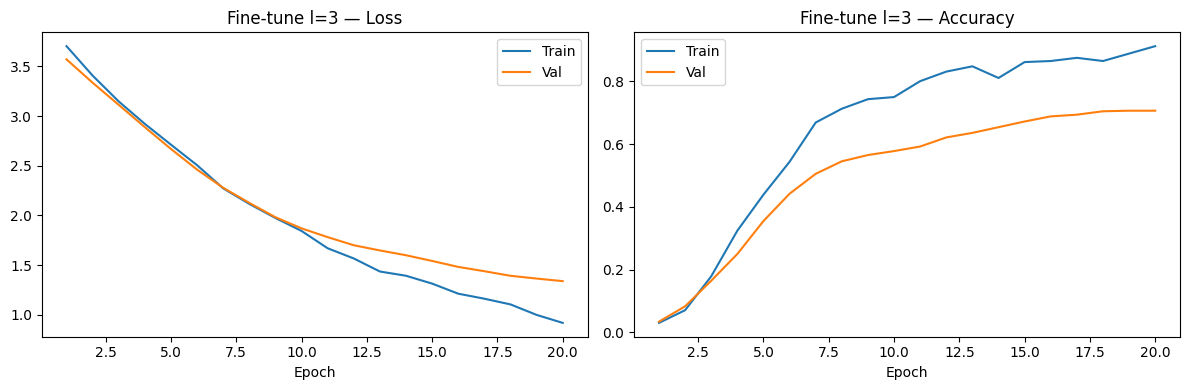

Fine-tune l=3 test accuracy: 69.07%
[GradUnfreeze] Epoch 1/20, train acc 0.0405, val acc 0.0507
[GradUnfreeze] Epoch 2/20, train acc 0.0541, val acc 0.0489
[GradUnfreeze] Epoch 3/20, train acc 0.0608, val acc 0.0507
[GradUnfreeze] Epoch 4/20, train acc 0.0574, val acc 0.0616
[GradUnfreeze] Epoch 5/20, train acc 0.0405, val acc 0.0634
Epoch 6: unfroze 5
[GradUnfreeze] Epoch 6/20, train acc 0.0946, val acc 0.1884
[GradUnfreeze] Epoch 7/20, train acc 0.2939, val acc 0.3351
[GradUnfreeze] Epoch 8/20, train acc 0.5574, val acc 0.4692
[GradUnfreeze] Epoch 9/20, train acc 0.6047, val acc 0.5471
[GradUnfreeze] Epoch 10/20, train acc 0.7095, val acc 0.6141
Epoch 11: unfroze 10
[GradUnfreeze] Epoch 11/20, train acc 0.7601, val acc 0.6377
[GradUnfreeze] Epoch 12/20, train acc 0.8176, val acc 0.6902
[GradUnfreeze] Epoch 13/20, train acc 0.8480, val acc 0.7156
[GradUnfreeze] Epoch 14/20, train acc 0.8649, val acc 0.7355
[GradUnfreeze] Epoch 15/20, train acc 0.8480, val acc 0.7500
Epoch 16: unfroze 

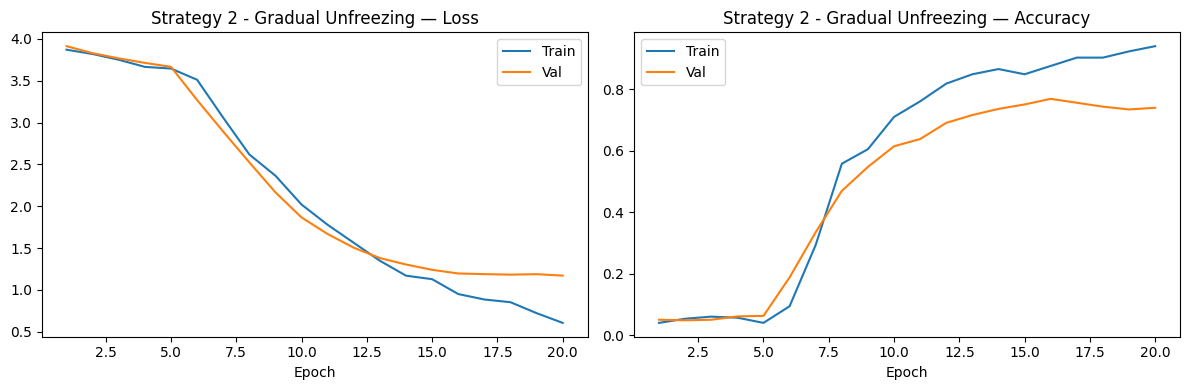

Strategy 2 test accuracy: 73.56%


In [ ]:
# 10%
train_loader_stratified = stratify_traindata(train_aug_dataset, 0.1)
run_tests(train_loader_stratified, val_loader)

[FT l=3] Epoch 1/20, train acc 0.0000, val acc 0.0344
[FT l=3] Epoch 2/20, train acc 0.0000, val acc 0.0380
[FT l=3] Epoch 3/20, train acc 0.0270, val acc 0.0435
[FT l=3] Epoch 4/20, train acc 0.0541, val acc 0.0525
[FT l=3] Epoch 5/20, train acc 0.0811, val acc 0.0562
[FT l=3] Epoch 6/20, train acc 0.1081, val acc 0.0670
[FT l=3] Epoch 7/20, train acc 0.2162, val acc 0.0743
[FT l=3] Epoch 8/20, train acc 0.4054, val acc 0.0815
[FT l=3] Epoch 9/20, train acc 0.2703, val acc 0.0870
[FT l=3] Epoch 10/20, train acc 0.4054, val acc 0.0942
[FT l=3] Epoch 11/20, train acc 0.4324, val acc 0.1033
[FT l=3] Epoch 12/20, train acc 0.4595, val acc 0.1123
[FT l=3] Epoch 13/20, train acc 0.6486, val acc 0.1232
[FT l=3] Epoch 14/20, train acc 0.5946, val acc 0.1413
[FT l=3] Epoch 15/20, train acc 0.6486, val acc 0.1540
[FT l=3] Epoch 16/20, train acc 0.7838, val acc 0.1594
[FT l=3] Epoch 17/20, train acc 0.7838, val acc 0.1703
[FT l=3] Epoch 18/20, train acc 0.8378, val acc 0.1812
[FT l=3] Epoch 19/2

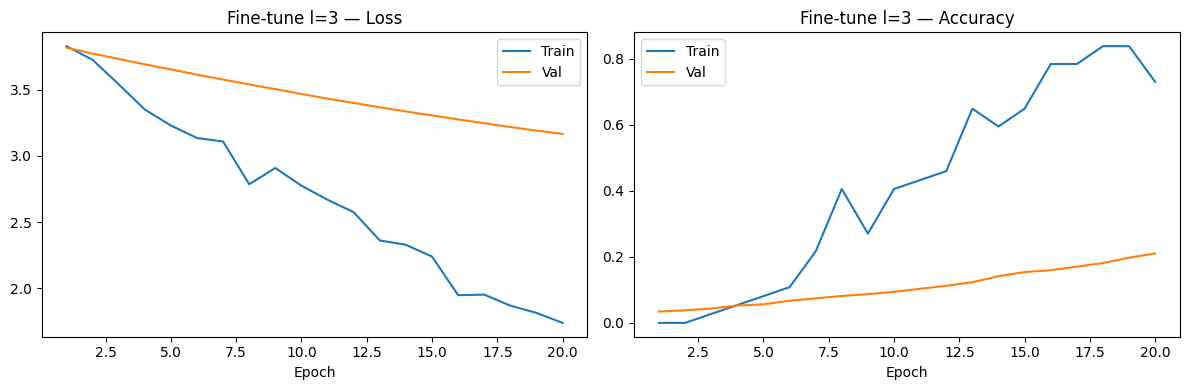

Fine-tune l=3 test accuracy: 19.13%
[GradUnfreeze] Epoch 1/20, train acc 0.0270, val acc 0.0326
[GradUnfreeze] Epoch 2/20, train acc 0.0270, val acc 0.0344
[GradUnfreeze] Epoch 3/20, train acc 0.0541, val acc 0.0362
[GradUnfreeze] Epoch 4/20, train acc 0.0541, val acc 0.0308
[GradUnfreeze] Epoch 5/20, train acc 0.0270, val acc 0.0308
Epoch 6: unfroze 5
[GradUnfreeze] Epoch 6/20, train acc 0.0000, val acc 0.0399
[GradUnfreeze] Epoch 7/20, train acc 0.1081, val acc 0.0543
[GradUnfreeze] Epoch 8/20, train acc 0.1622, val acc 0.0634
[GradUnfreeze] Epoch 9/20, train acc 0.2973, val acc 0.0851
[GradUnfreeze] Epoch 10/20, train acc 0.4595, val acc 0.1123
Epoch 11: unfroze 10
[GradUnfreeze] Epoch 11/20, train acc 0.7297, val acc 0.1467
[GradUnfreeze] Epoch 12/20, train acc 0.7297, val acc 0.1721
[GradUnfreeze] Epoch 13/20, train acc 0.8108, val acc 0.1975
[GradUnfreeze] Epoch 14/20, train acc 0.8649, val acc 0.2120
[GradUnfreeze] Epoch 15/20, train acc 0.9459, val acc 0.2391
Epoch 16: unfroze 

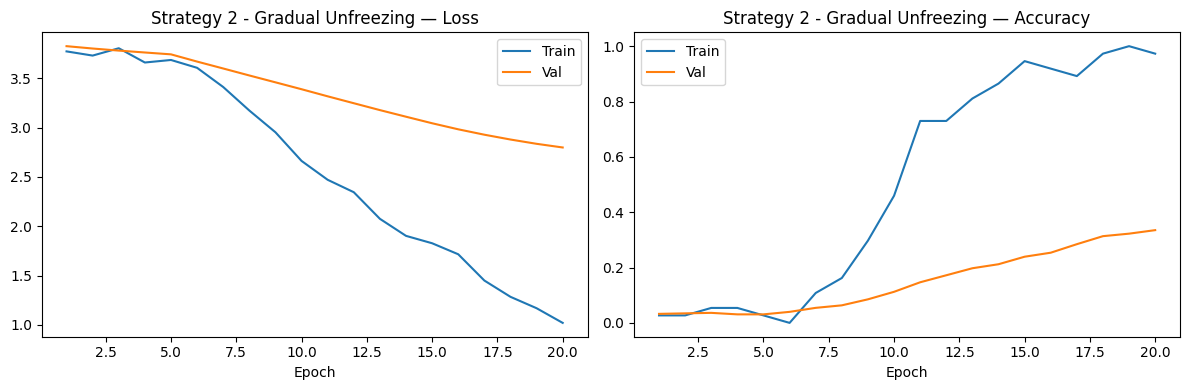

Strategy 2 test accuracy: 31.37%


In [ ]:
# 1 %
train_loader_stratified = stratify_traindata(train_aug_dataset, 0.01)
run_tests(train_loader_stratified, val_loader)

# **With L2 regularization**

[FT l=3] Epoch 1/20, train acc 0.3875, val acc 0.7446
[FT l=3] Epoch 2/20, train acc 0.8744, val acc 0.8659
[FT l=3] Epoch 3/20, train acc 0.9418, val acc 0.8986
[FT l=3] Epoch 4/20, train acc 0.9744, val acc 0.9167
[FT l=3] Epoch 5/20, train acc 0.9914, val acc 0.9185
[FT l=3] Epoch 6/20, train acc 0.9981, val acc 0.9239
[FT l=3] Epoch 7/20, train acc 1.0000, val acc 0.9257
[FT l=3] Epoch 8/20, train acc 1.0000, val acc 0.9239
[FT l=3] Epoch 9/20, train acc 1.0000, val acc 0.9330
[FT l=3] Epoch 10/20, train acc 1.0000, val acc 0.9275
[FT l=3] Epoch 11/20, train acc 1.0000, val acc 0.9330
[FT l=3] Epoch 12/20, train acc 1.0000, val acc 0.9257
[FT l=3] Epoch 13/20, train acc 1.0000, val acc 0.9293
[FT l=3] Epoch 14/20, train acc 1.0000, val acc 0.9239
[FT l=3] Epoch 15/20, train acc 1.0000, val acc 0.9257
[FT l=3] Epoch 16/20, train acc 1.0000, val acc 0.9239
[FT l=3] Epoch 17/20, train acc 1.0000, val acc 0.9293
[FT l=3] Epoch 18/20, train acc 1.0000, val acc 0.9257
[FT l=3] Epoch 19/2

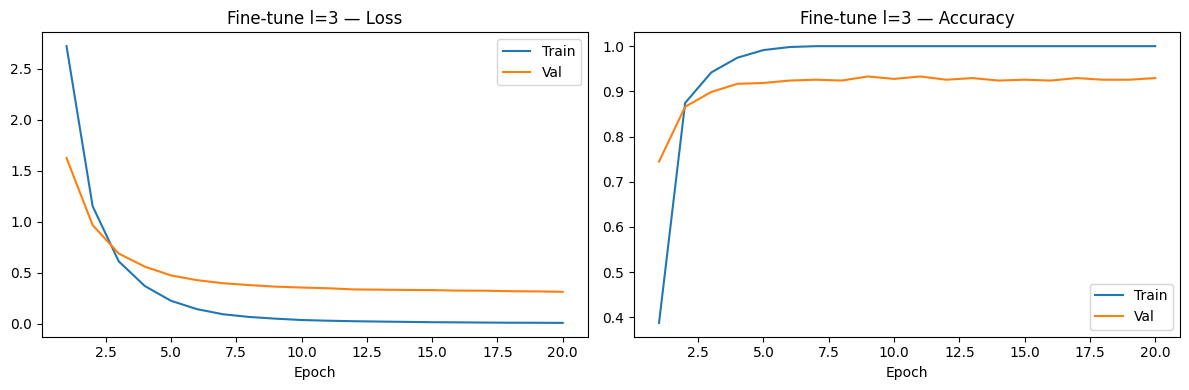

Fine-tune l=3 test accuracy: 89.13%
[GradUnfreeze] Epoch 1/20, train acc 0.0707, val acc 0.1322
[GradUnfreeze] Epoch 2/20, train acc 0.2247, val acc 0.3388
[GradUnfreeze] Epoch 3/20, train acc 0.4162, val acc 0.4783
[GradUnfreeze] Epoch 4/20, train acc 0.5646, val acc 0.5906
[GradUnfreeze] Epoch 5/20, train acc 0.6650, val acc 0.6775
Epoch 6: unfroze 5
[GradUnfreeze] Epoch 6/20, train acc 0.8245, val acc 0.8714
[GradUnfreeze] Epoch 7/20, train acc 0.9511, val acc 0.9040
[GradUnfreeze] Epoch 8/20, train acc 0.9843, val acc 0.9112
[GradUnfreeze] Epoch 9/20, train acc 0.9968, val acc 0.9185
[GradUnfreeze] Epoch 10/20, train acc 1.0000, val acc 0.9221
Epoch 11: unfroze 10
[GradUnfreeze] Epoch 11/20, train acc 1.0000, val acc 0.9203
[GradUnfreeze] Epoch 12/20, train acc 1.0000, val acc 0.9239
[GradUnfreeze] Epoch 13/20, train acc 1.0000, val acc 0.9312
[GradUnfreeze] Epoch 14/20, train acc 1.0000, val acc 0.9275
[GradUnfreeze] Epoch 15/20, train acc 1.0000, val acc 0.9330
Epoch 16: unfroze 

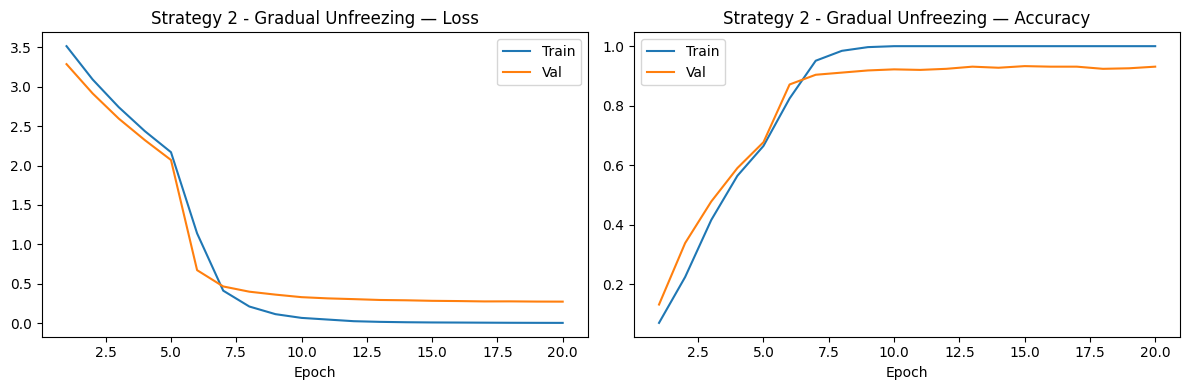

Strategy 2 test accuracy: 89.56%


In [ ]:
# 100%
run_tests(train_loader, val_loader, L2 = 1e-4)

[FT l=3] Epoch 1/20, train acc 0.0270, val acc 0.0344
[FT l=3] Epoch 2/20, train acc 0.1824, val acc 0.0707
[FT l=3] Epoch 3/20, train acc 0.5405, val acc 0.1649
[FT l=3] Epoch 4/20, train acc 0.8108, val acc 0.2844
[FT l=3] Epoch 5/20, train acc 0.9324, val acc 0.3732
[FT l=3] Epoch 6/20, train acc 0.9932, val acc 0.4529
[FT l=3] Epoch 7/20, train acc 0.9966, val acc 0.5163
[FT l=3] Epoch 8/20, train acc 0.9966, val acc 0.5562
[FT l=3] Epoch 9/20, train acc 1.0000, val acc 0.5851
[FT l=3] Epoch 10/20, train acc 1.0000, val acc 0.6159
[FT l=3] Epoch 11/20, train acc 1.0000, val acc 0.6286
[FT l=3] Epoch 12/20, train acc 1.0000, val acc 0.6431
[FT l=3] Epoch 13/20, train acc 1.0000, val acc 0.6576
[FT l=3] Epoch 14/20, train acc 1.0000, val acc 0.6612
[FT l=3] Epoch 15/20, train acc 1.0000, val acc 0.6685
[FT l=3] Epoch 16/20, train acc 1.0000, val acc 0.6649
[FT l=3] Epoch 17/20, train acc 1.0000, val acc 0.6739
[FT l=3] Epoch 18/20, train acc 1.0000, val acc 0.6757
[FT l=3] Epoch 19/2

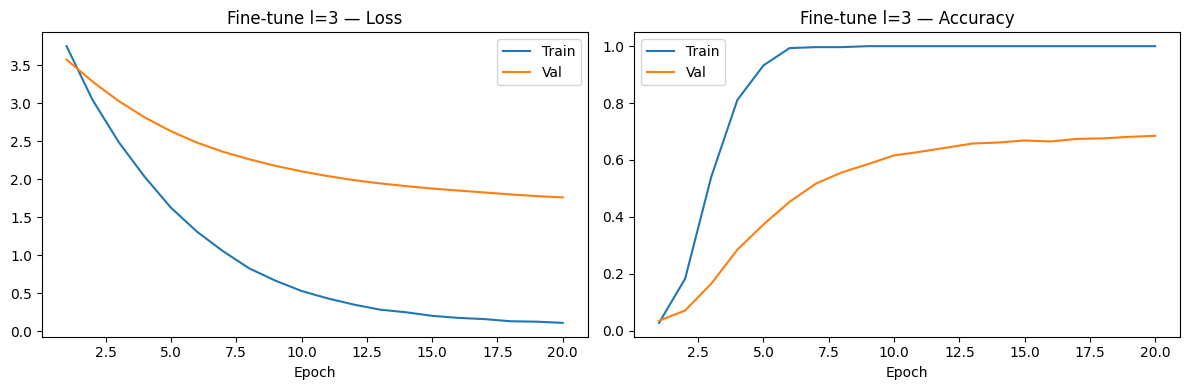

Fine-tune l=3 test accuracy: 68.06%
[GradUnfreeze] Epoch 1/20, train acc 0.0642, val acc 0.0797
[GradUnfreeze] Epoch 2/20, train acc 0.0845, val acc 0.0797
[GradUnfreeze] Epoch 3/20, train acc 0.0777, val acc 0.0906
[GradUnfreeze] Epoch 4/20, train acc 0.0777, val acc 0.0906
[GradUnfreeze] Epoch 5/20, train acc 0.1149, val acc 0.0924
Epoch 6: unfroze 5
[GradUnfreeze] Epoch 6/20, train acc 0.1757, val acc 0.3080
[GradUnfreeze] Epoch 7/20, train acc 0.7973, val acc 0.5163
[GradUnfreeze] Epoch 8/20, train acc 0.9730, val acc 0.6178
[GradUnfreeze] Epoch 9/20, train acc 1.0000, val acc 0.6739
[GradUnfreeze] Epoch 10/20, train acc 1.0000, val acc 0.7192
Epoch 11: unfroze 10
[GradUnfreeze] Epoch 11/20, train acc 1.0000, val acc 0.7482
[GradUnfreeze] Epoch 12/20, train acc 1.0000, val acc 0.7518
[GradUnfreeze] Epoch 13/20, train acc 1.0000, val acc 0.7554
[GradUnfreeze] Epoch 14/20, train acc 1.0000, val acc 0.7572
[GradUnfreeze] Epoch 15/20, train acc 1.0000, val acc 0.7518
Epoch 16: unfroze 

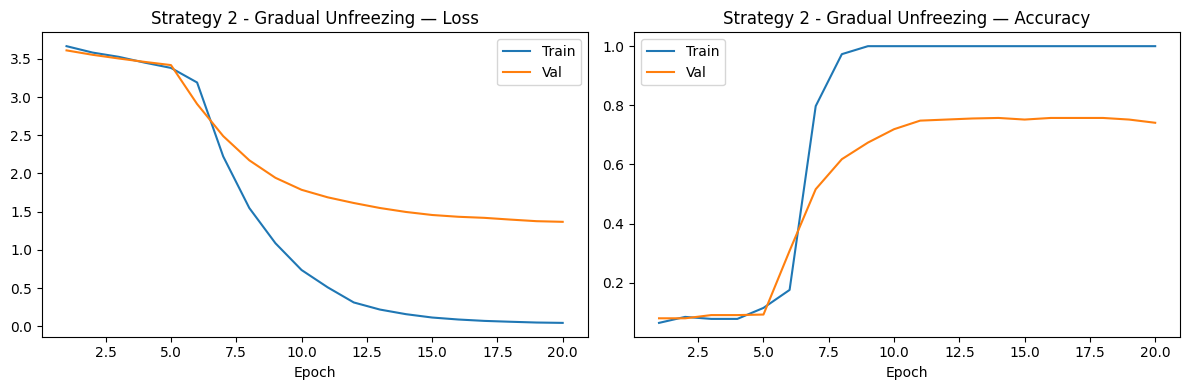

Strategy 2 test accuracy: 72.94%


In [ ]:
# 10%
train_loader_stratified = stratify_traindata(train_dataset, 0.1)
run_tests(train_loader_stratified, val_loader, L2 =  1e-4)

[FT l=3] Epoch 1/20, train acc 0.0270, val acc 0.0109
[FT l=3] Epoch 2/20, train acc 0.1351, val acc 0.0127
[FT l=3] Epoch 3/20, train acc 0.3784, val acc 0.0163
[FT l=3] Epoch 4/20, train acc 0.5946, val acc 0.0254
[FT l=3] Epoch 5/20, train acc 0.7838, val acc 0.0435
[FT l=3] Epoch 6/20, train acc 0.9189, val acc 0.0562
[FT l=3] Epoch 7/20, train acc 1.0000, val acc 0.0616
[FT l=3] Epoch 8/20, train acc 1.0000, val acc 0.0707
[FT l=3] Epoch 9/20, train acc 1.0000, val acc 0.0924
[FT l=3] Epoch 10/20, train acc 1.0000, val acc 0.1141
[FT l=3] Epoch 11/20, train acc 1.0000, val acc 0.1304
[FT l=3] Epoch 12/20, train acc 1.0000, val acc 0.1322
[FT l=3] Epoch 13/20, train acc 1.0000, val acc 0.1413
[FT l=3] Epoch 14/20, train acc 1.0000, val acc 0.1522
[FT l=3] Epoch 15/20, train acc 1.0000, val acc 0.1558
[FT l=3] Epoch 16/20, train acc 1.0000, val acc 0.1576
[FT l=3] Epoch 17/20, train acc 1.0000, val acc 0.1667
[FT l=3] Epoch 18/20, train acc 1.0000, val acc 0.1775
[FT l=3] Epoch 19/2

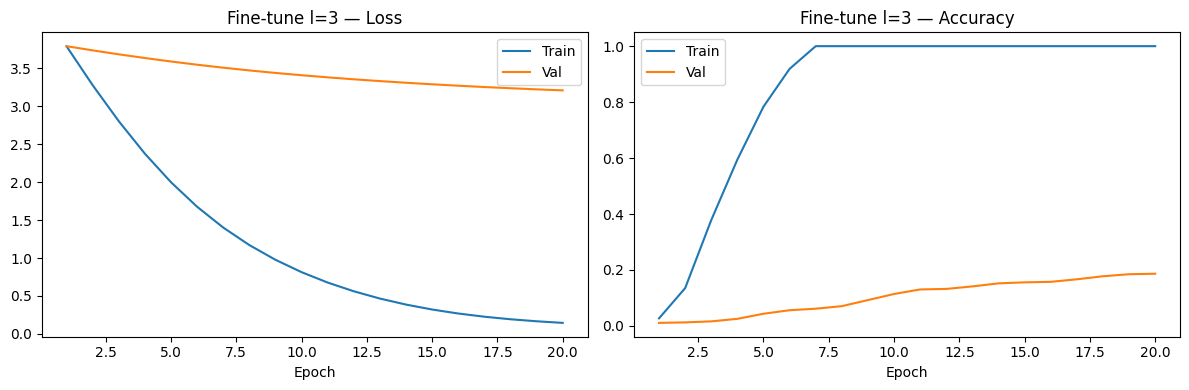

Fine-tune l=3 test accuracy: 19.62%
[GradUnfreeze] Epoch 1/20, train acc 0.0270, val acc 0.0199
[GradUnfreeze] Epoch 2/20, train acc 0.0270, val acc 0.0199
[GradUnfreeze] Epoch 3/20, train acc 0.0270, val acc 0.0199
[GradUnfreeze] Epoch 4/20, train acc 0.0270, val acc 0.0217
[GradUnfreeze] Epoch 5/20, train acc 0.0270, val acc 0.0254
Epoch 6: unfroze 5
[GradUnfreeze] Epoch 6/20, train acc 0.0270, val acc 0.0380
[GradUnfreeze] Epoch 7/20, train acc 0.3514, val acc 0.0688
[GradUnfreeze] Epoch 8/20, train acc 0.8649, val acc 0.0924
[GradUnfreeze] Epoch 9/20, train acc 1.0000, val acc 0.1178
[GradUnfreeze] Epoch 10/20, train acc 1.0000, val acc 0.1594
Epoch 11: unfroze 10
[GradUnfreeze] Epoch 11/20, train acc 1.0000, val acc 0.1630
[GradUnfreeze] Epoch 12/20, train acc 1.0000, val acc 0.1884
[GradUnfreeze] Epoch 13/20, train acc 1.0000, val acc 0.2029
[GradUnfreeze] Epoch 14/20, train acc 1.0000, val acc 0.2156
[GradUnfreeze] Epoch 15/20, train acc 1.0000, val acc 0.2283
Epoch 16: unfroze 

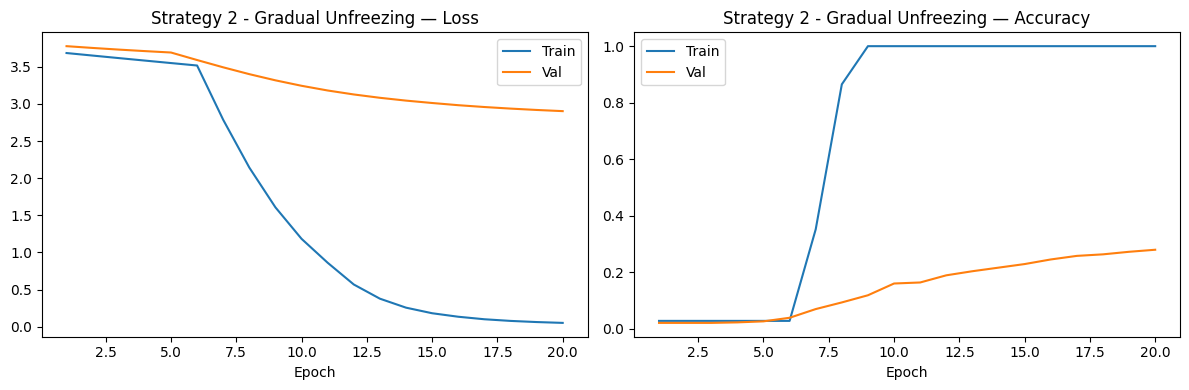

Strategy 2 test accuracy: 29.22%


In [ ]:
# 1%
train_loader_stratified = stratify_traindata(train_dataset, 0.01)
run_tests(train_loader_stratified, val_loader, L2 =  1e-3)

# **Imbalanced classes**

In [ ]:
def create_imbalanced_loader(dataset, minority_classes, minority_ratio, batch_size=64):
    class_indices = defaultdict(list)

    for idx in range(len(dataset)):
        label = dataset.dataset._labels[dataset.indices[idx]]
        class_indices[label].append(idx)

    selected_indices = []
    for cls, indices in class_indices.items():
        if cls in minority_classes:
            keep = max(1, int(len(indices) * minority_ratio))
            selected_indices.extend(indices[:keep])
        else:
            selected_indices.extend(indices)

    subset = torch.utils.data.Subset(dataset, selected_indices)
    loader = DataLoader(subset, batch_size=batch_size, shuffle=True,
                      num_workers=2, pin_memory=True)
    return subset, loader




def evaluate_adv(model, dataloader, class_names, cat_labels):

    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())


    # Overall Metrics


    overall_acc = accuracy_score(all_labels, all_preds)
    overall_f1 = f1_score(all_labels, all_preds, average="weighted")

    print(f"\nOverall Accuracy: {overall_acc:.4f}")
    print(f"Overall F1 Score: {overall_f1:.4f}")


    # Cat / Dog Metrics


    cat_labels = set(cat_labels)

    dog_labels = set(range(len(class_names))) - cat_labels

    # Cats
    cat_true = []
    cat_pred = []

    # Dogs
    dog_true = []
    dog_pred = []

    for true, pred in zip(all_labels, all_preds):

        if true in cat_labels:
            cat_true.append(true)
            cat_pred.append(pred)

        elif true in dog_labels:
            dog_true.append(true)
            dog_pred.append(pred)

    # Cat metrics
    cat_acc = accuracy_score(cat_true, cat_pred)

    cat_f1 = f1_score(
        cat_true,
        cat_pred,
        average="weighted"
    )

    # Dog metrics
    dog_acc = accuracy_score(dog_true, dog_pred)

    dog_f1 = f1_score(
        dog_true,
        dog_pred,
        average="weighted"
    )

    print(f"\nCat Accuracy: {cat_acc:.4f}")
    print(f"Cat F1 Score: {cat_f1:.4f}")

    print(f"\nDog Accuracy: {dog_acc:.4f}")
    print(f"Dog F1 Score: {dog_f1:.4f}")




    report = classification_report(
        all_labels,
        all_preds,
        target_names=class_names,
        output_dict=True
    )

    report_df = pd.DataFrame(report).transpose()

    print("\nClassification Report:")
    display(report_df)

    # Confusion Matrix


    cm = confusion_matrix(all_labels, all_preds)

    fig, ax = plt.subplots(figsize=(14, 14))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    )

    disp.plot(
        ax=ax,
        xticks_rotation=90,
        colorbar=True
    )

    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return {
        "overall_accuracy": overall_acc,
        "overall_f1": overall_f1,
        "cat_accuracy": cat_acc,
        "cat_f1": cat_f1,
        "dog_accuracy": dog_acc,
        "dog_f1": dog_f1,
        "classification_report": report_df,
        "confusion_matrix": cm
    }

In [ ]:
# Only use full_dataset to get cat labels — don't create a new val_loader from it
full_dataset = datasets.OxfordIIITPet(
    root="./data", split="trainval",
    target_types=("category", "binary-category"),
    transform=data_transforms["train"], download=False
)

cat_labels = {
    breed_label
    for _, (breed_label, species_label) in full_dataset
    if species_label == 0
}
print(f"Cat breed indices: {sorted(cat_labels)}")

# Use the original val_loader from the top of the notebook
imbalanced_dataset, imbalanced_loader = create_imbalanced_loader(train_dataset, minority_classes=cat_labels, minority_ratio=0.2)
print(f"Imbalanced train size: {len(imbalanced_loader.dataset)}")

class_names = train_dataset.dataset.classes

Cat breed indices: [0, 5, 6, 7, 9, 11, 20, 23, 26, 27, 32, 33]
Imbalanced train size: 2318


[FT l=3] Epoch 1/20, train acc 0.3783, val acc 0.4855
[FT l=3] Epoch 2/20, train acc 0.8067, val acc 0.5978
[FT l=3] Epoch 3/20, train acc 0.8934, val acc 0.6920
[FT l=3] Epoch 4/20, train acc 0.9521, val acc 0.7609
[FT l=3] Epoch 5/20, train acc 0.9862, val acc 0.8080
[FT l=3] Epoch 6/20, train acc 0.9940, val acc 0.8351
[FT l=3] Epoch 7/20, train acc 0.9991, val acc 0.8514
[FT l=3] Epoch 8/20, train acc 1.0000, val acc 0.8623
[FT l=3] Epoch 9/20, train acc 1.0000, val acc 0.8786
[FT l=3] Epoch 10/20, train acc 1.0000, val acc 0.8678
[FT l=3] Epoch 11/20, train acc 1.0000, val acc 0.8678
[FT l=3] Epoch 12/20, train acc 1.0000, val acc 0.8678
[FT l=3] Epoch 13/20, train acc 1.0000, val acc 0.8659
[FT l=3] Epoch 14/20, train acc 1.0000, val acc 0.8678
[FT l=3] Epoch 15/20, train acc 1.0000, val acc 0.8623
[FT l=3] Epoch 16/20, train acc 1.0000, val acc 0.8714
[FT l=3] Epoch 17/20, train acc 1.0000, val acc 0.8714
[FT l=3] Epoch 18/20, train acc 1.0000, val acc 0.8587
[FT l=3] Epoch 19/2

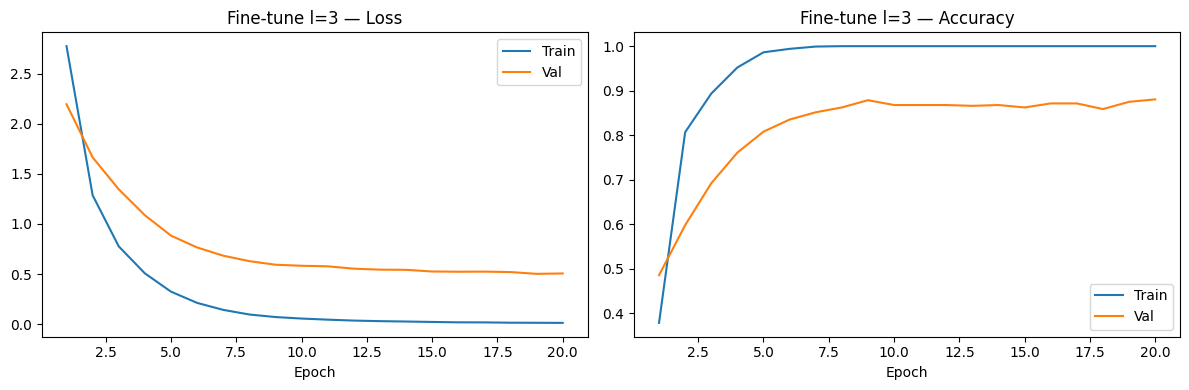


Overall Accuracy: 0.8337
Overall F1 Score: 0.8297

Cat Accuracy: 0.6948
Cat F1 Score: 0.7440

Dog Accuracy: 0.8998
Dog F1 Score: 0.8979

Classification Report:


,precision,recall,f1-score,support
Abyssinian,0.737864,0.775510,0.756219,98.000000
American Bulldog,0.642857,0.900000,0.750000,100.000000
American Pit Bull Terrier,0.689655,0.400000,0.506329,100.000000
Basset Hound,0.910000,0.910000,0.910000,100.000000
Beagle,0.885714,0.930000,0.907317,100.000000
Bengal,0.762376,0.770000,0.766169,100.000000
Birman,0.744898,0.730000,0.737374,100.000000
Bombay,0.774194,0.818182,0.795580,88.000000
Boxer,0.781818,0.868687,0.822967,99.000000
British Shorthair,0.967213,0.590000,0.732919,100.000000


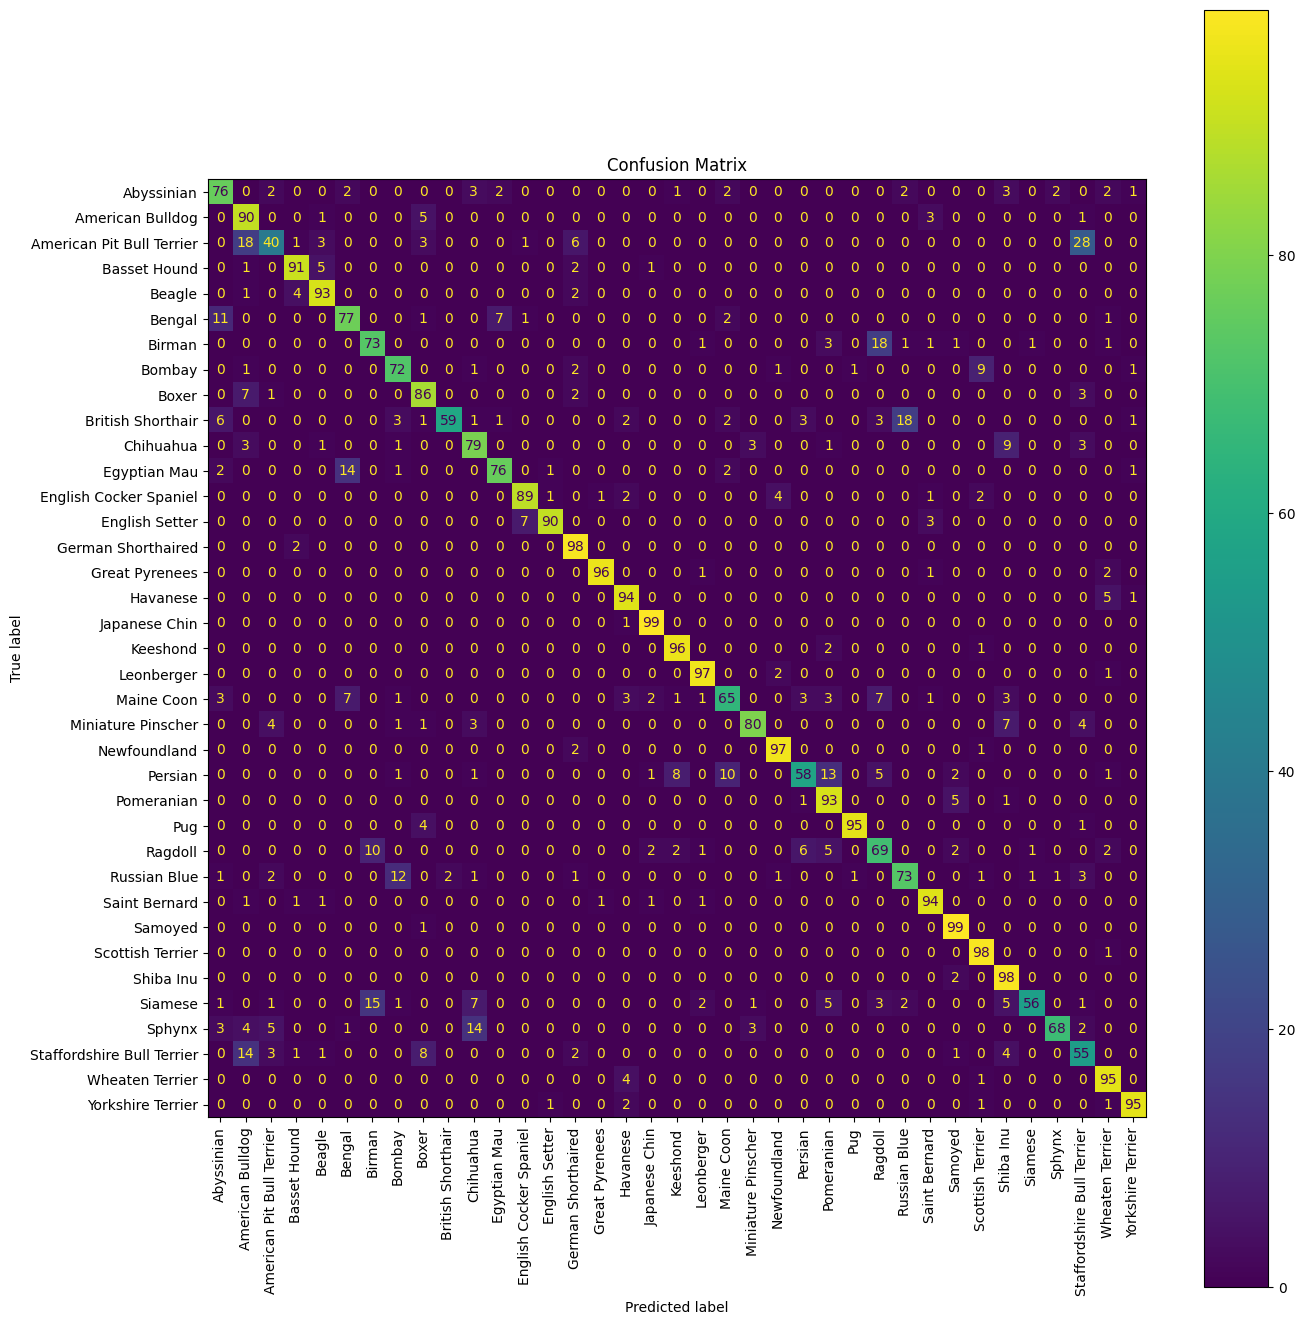

[GradUnfreeze] Epoch 1/20, train acc 0.0764, val acc 0.1033
[GradUnfreeze] Epoch 2/20, train acc 0.2295, val acc 0.2101
[GradUnfreeze] Epoch 3/20, train acc 0.3775, val acc 0.3279
[GradUnfreeze] Epoch 4/20, train acc 0.5047, val acc 0.3913
[GradUnfreeze] Epoch 5/20, train acc 0.5854, val acc 0.4312
Epoch 6: unfroze 5
[GradUnfreeze] Epoch 6/20, train acc 0.7545, val acc 0.6866
[GradUnfreeze] Epoch 7/20, train acc 0.9284, val acc 0.8297
[GradUnfreeze] Epoch 8/20, train acc 0.9806, val acc 0.8732
[GradUnfreeze] Epoch 9/20, train acc 0.9953, val acc 0.8804
[GradUnfreeze] Epoch 10/20, train acc 1.0000, val acc 0.8822
Epoch 11: unfroze 10
[GradUnfreeze] Epoch 11/20, train acc 1.0000, val acc 0.8732
[GradUnfreeze] Epoch 12/20, train acc 1.0000, val acc 0.8786
[GradUnfreeze] Epoch 13/20, train acc 1.0000, val acc 0.8804
[GradUnfreeze] Epoch 14/20, train acc 0.9996, val acc 0.8841
[GradUnfreeze] Epoch 15/20, train acc 1.0000, val acc 0.8750
Epoch 16: unfroze 15
[GradUnfreeze] Epoch 16/20, train

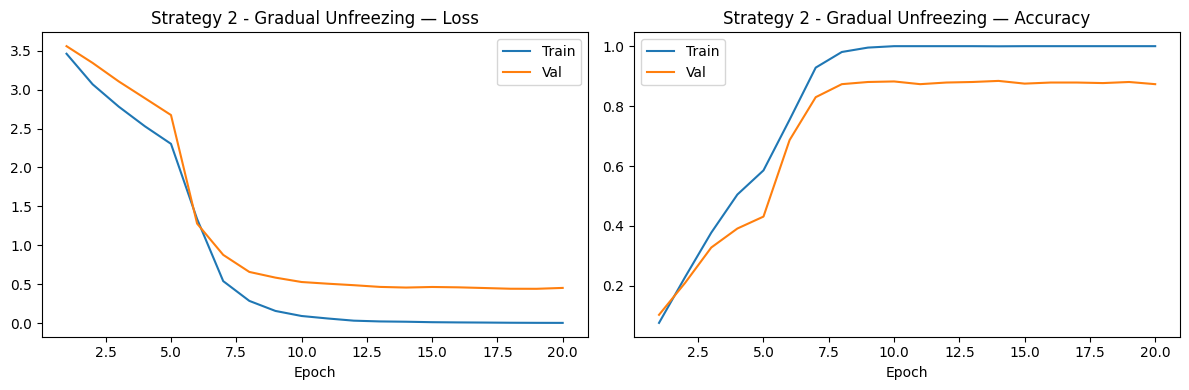


Overall Accuracy: 0.8577
Overall F1 Score: 0.8542

Cat Accuracy: 0.7346
Cat F1 Score: 0.7727

Dog Accuracy: 0.9163
Dog F1 Score: 0.9143

Classification Report:


,precision,recall,f1-score,support
Abyssinian,0.811111,0.744898,0.776596,98.000000
American Bulldog,0.671756,0.880000,0.761905,100.000000
American Pit Bull Terrier,0.728814,0.430000,0.540881,100.000000
Basset Hound,0.938144,0.910000,0.923858,100.000000
Beagle,0.869159,0.930000,0.898551,100.000000
Bengal,0.745283,0.790000,0.766990,100.000000
Birman,0.762887,0.740000,0.751269,100.000000
Bombay,0.852632,0.920455,0.885246,88.000000
Boxer,0.782609,0.909091,0.841121,99.000000
British Shorthair,0.859375,0.550000,0.670732,100.000000


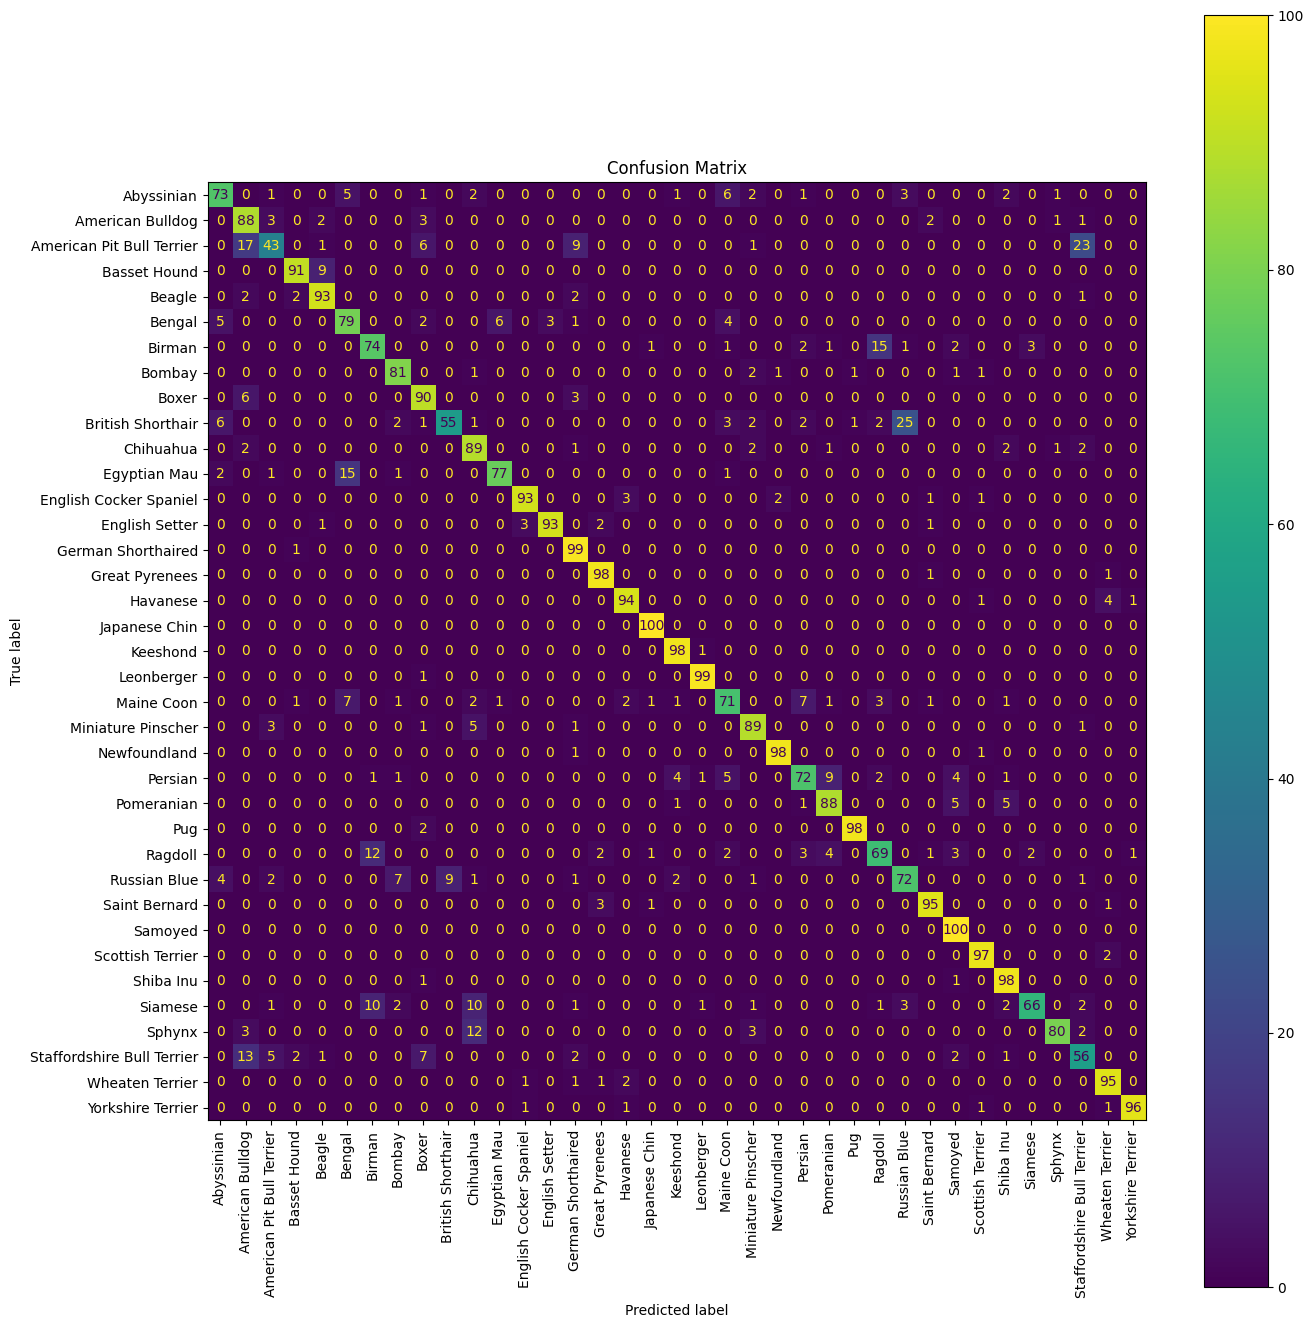

In [ ]:
run_tests(imbalanced_loader, val_loader, advanced_eval=True, class_names=class_names, cat_labels = cat_labels)

[FT l=3] Epoch 1/20, train acc 0.2355, val acc 0.5308
[FT l=3] Epoch 2/20, train acc 0.7890, val acc 0.7446
[FT l=3] Epoch 3/20, train acc 0.9060, val acc 0.8098
[FT l=3] Epoch 4/20, train acc 0.9469, val acc 0.8496
[FT l=3] Epoch 5/20, train acc 0.9689, val acc 0.8623
[FT l=3] Epoch 6/20, train acc 0.9806, val acc 0.8714
[FT l=3] Epoch 7/20, train acc 0.9922, val acc 0.8714
[FT l=3] Epoch 8/20, train acc 0.9957, val acc 0.8786
[FT l=3] Epoch 9/20, train acc 0.9987, val acc 0.8714
[FT l=3] Epoch 10/20, train acc 0.9991, val acc 0.8696
[FT l=3] Epoch 11/20, train acc 1.0000, val acc 0.8659
[FT l=3] Epoch 12/20, train acc 1.0000, val acc 0.8714
[FT l=3] Epoch 13/20, train acc 1.0000, val acc 0.8714
[FT l=3] Epoch 14/20, train acc 1.0000, val acc 0.8732
[FT l=3] Epoch 15/20, train acc 1.0000, val acc 0.8750
[FT l=3] Epoch 16/20, train acc 1.0000, val acc 0.8696
[FT l=3] Epoch 17/20, train acc 1.0000, val acc 0.8750
[FT l=3] Epoch 18/20, train acc 1.0000, val acc 0.8732
[FT l=3] Epoch 19/2

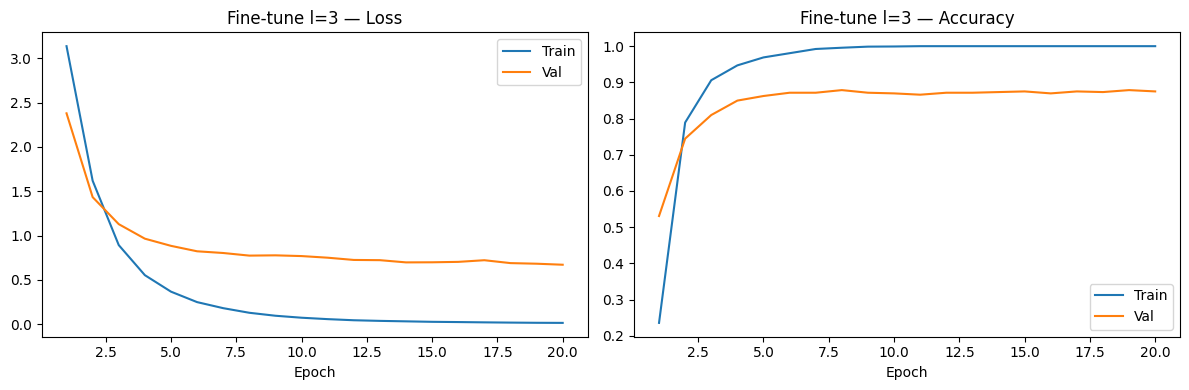


Overall Accuracy: 0.8362
Overall F1 Score: 0.8335

Cat Accuracy: 0.7185
Cat F1 Score: 0.7551

Dog Accuracy: 0.8922
Dog F1 Score: 0.8897

Classification Report:


,precision,recall,f1-score,support
Abyssinian,0.781609,0.693878,0.735135,98.000000
American Bulldog,0.630137,0.920000,0.747967,100.000000
American Pit Bull Terrier,0.645161,0.400000,0.493827,100.000000
Basset Hound,0.910891,0.920000,0.915423,100.000000
Beagle,0.836364,0.920000,0.876190,100.000000
Bengal,0.776699,0.800000,0.788177,100.000000
Birman,0.727273,0.720000,0.723618,100.000000
Bombay,0.817204,0.863636,0.839779,88.000000
Boxer,0.836735,0.828283,0.832487,99.000000
British Shorthair,0.810811,0.600000,0.689655,100.000000


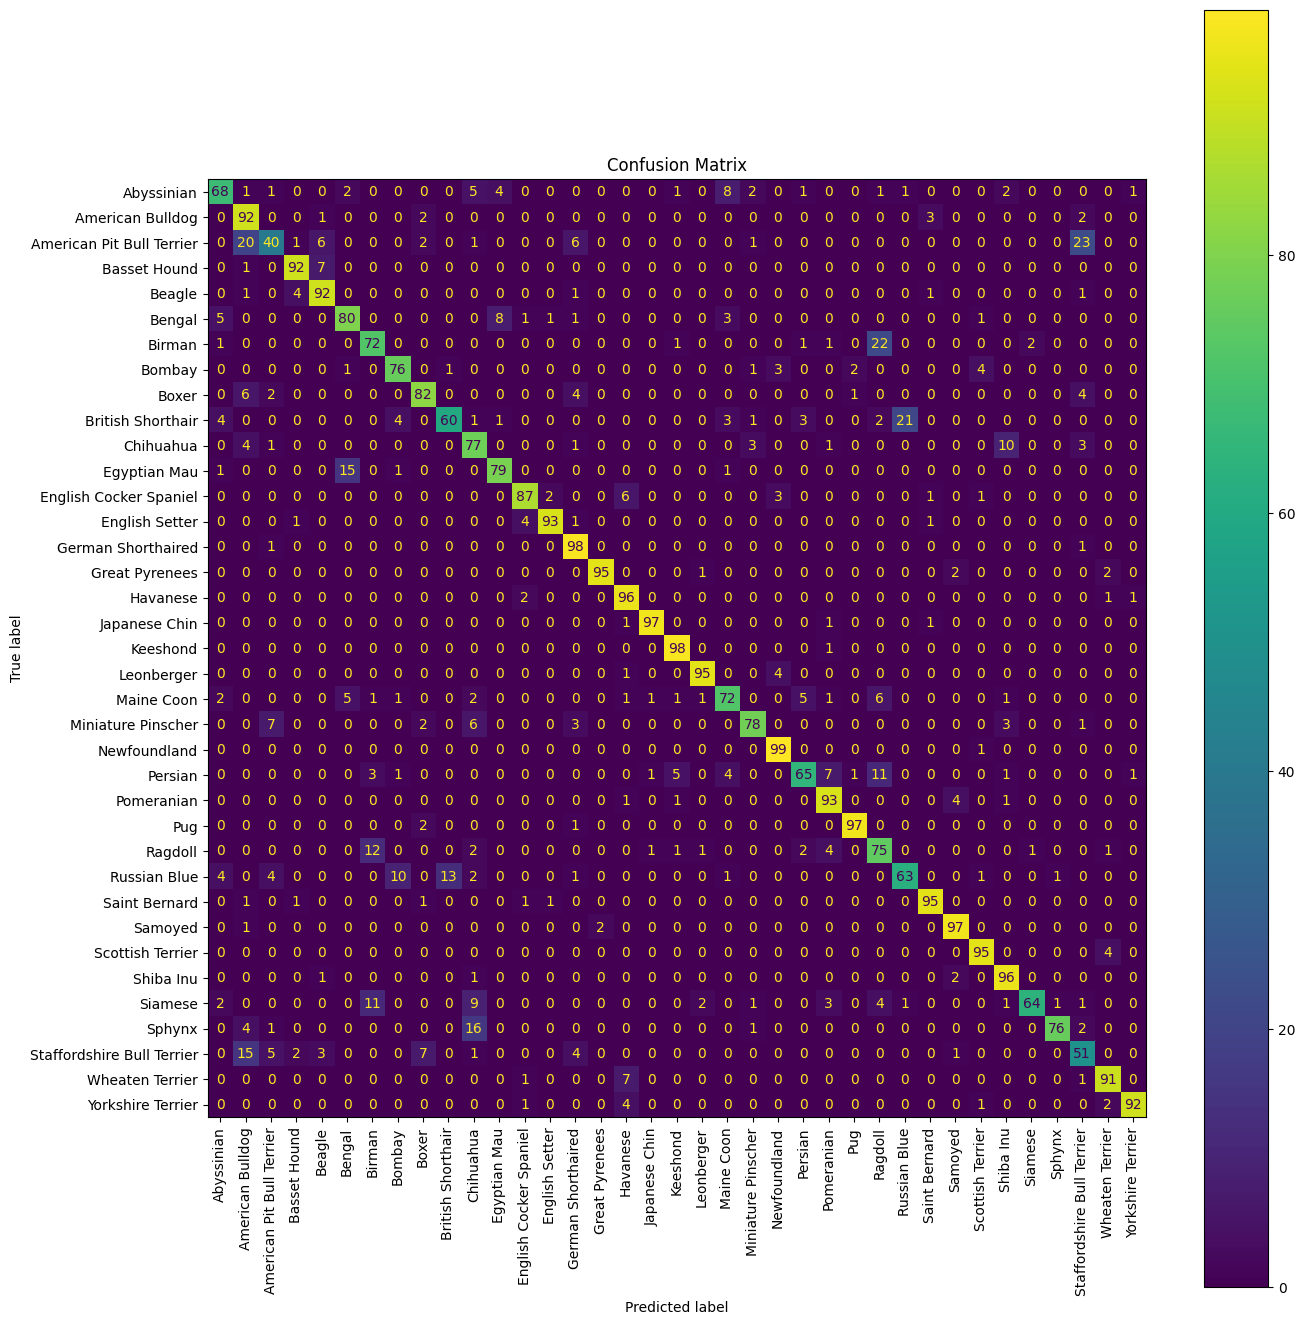

[GradUnfreeze] Epoch 1/20, train acc 0.0669, val acc 0.0833
[GradUnfreeze] Epoch 2/20, train acc 0.1903, val acc 0.1830
[GradUnfreeze] Epoch 3/20, train acc 0.3257, val acc 0.2681
[GradUnfreeze] Epoch 4/20, train acc 0.4435, val acc 0.3478
[GradUnfreeze] Epoch 5/20, train acc 0.5582, val acc 0.4348
Epoch 6: unfroze 5
[GradUnfreeze] Epoch 6/20, train acc 0.7498, val acc 0.6486
[GradUnfreeze] Epoch 7/20, train acc 0.9198, val acc 0.8080
[GradUnfreeze] Epoch 8/20, train acc 0.9776, val acc 0.8496
[GradUnfreeze] Epoch 9/20, train acc 0.9948, val acc 0.8623
[GradUnfreeze] Epoch 10/20, train acc 1.0000, val acc 0.8659
Epoch 11: unfroze 10
[GradUnfreeze] Epoch 11/20, train acc 1.0000, val acc 0.8714
[GradUnfreeze] Epoch 12/20, train acc 1.0000, val acc 0.8786
[GradUnfreeze] Epoch 13/20, train acc 1.0000, val acc 0.8877
[GradUnfreeze] Epoch 14/20, train acc 1.0000, val acc 0.8714
[GradUnfreeze] Epoch 15/20, train acc 1.0000, val acc 0.8895
Epoch 16: unfroze 15
[GradUnfreeze] Epoch 16/20, train

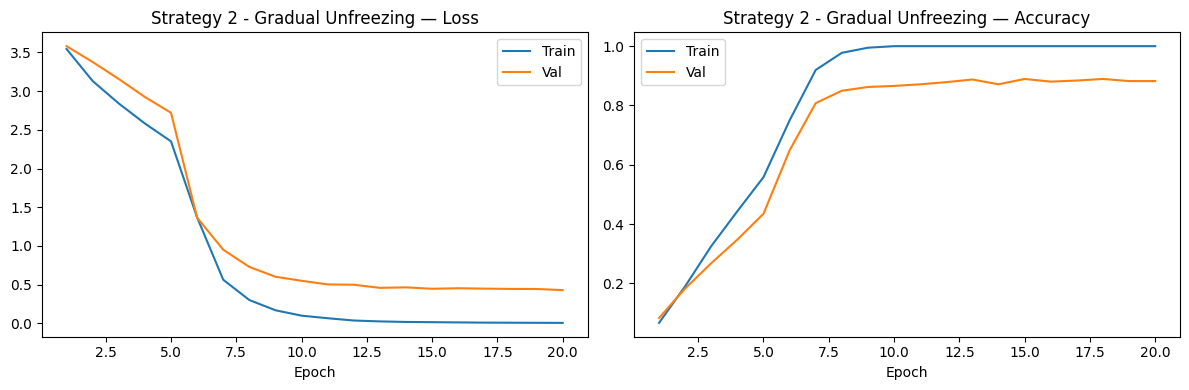


Overall Accuracy: 0.8539
Overall F1 Score: 0.8509

Cat Accuracy: 0.7371
Cat F1 Score: 0.7741

Dog Accuracy: 0.9095
Dog F1 Score: 0.9074

Classification Report:


,precision,recall,f1-score,support
Abyssinian,0.765957,0.734694,0.750000,98.000000
American Bulldog,0.666667,0.880000,0.758621,100.000000
American Pit Bull Terrier,0.745098,0.380000,0.503311,100.000000
Basset Hound,0.880734,0.960000,0.918660,100.000000
Beagle,0.920792,0.930000,0.925373,100.000000
Bengal,0.775510,0.760000,0.767677,100.000000
Birman,0.672727,0.740000,0.704762,100.000000
Bombay,0.824176,0.852273,0.837989,88.000000
Boxer,0.776786,0.878788,0.824645,99.000000
British Shorthair,0.953846,0.620000,0.751515,100.000000


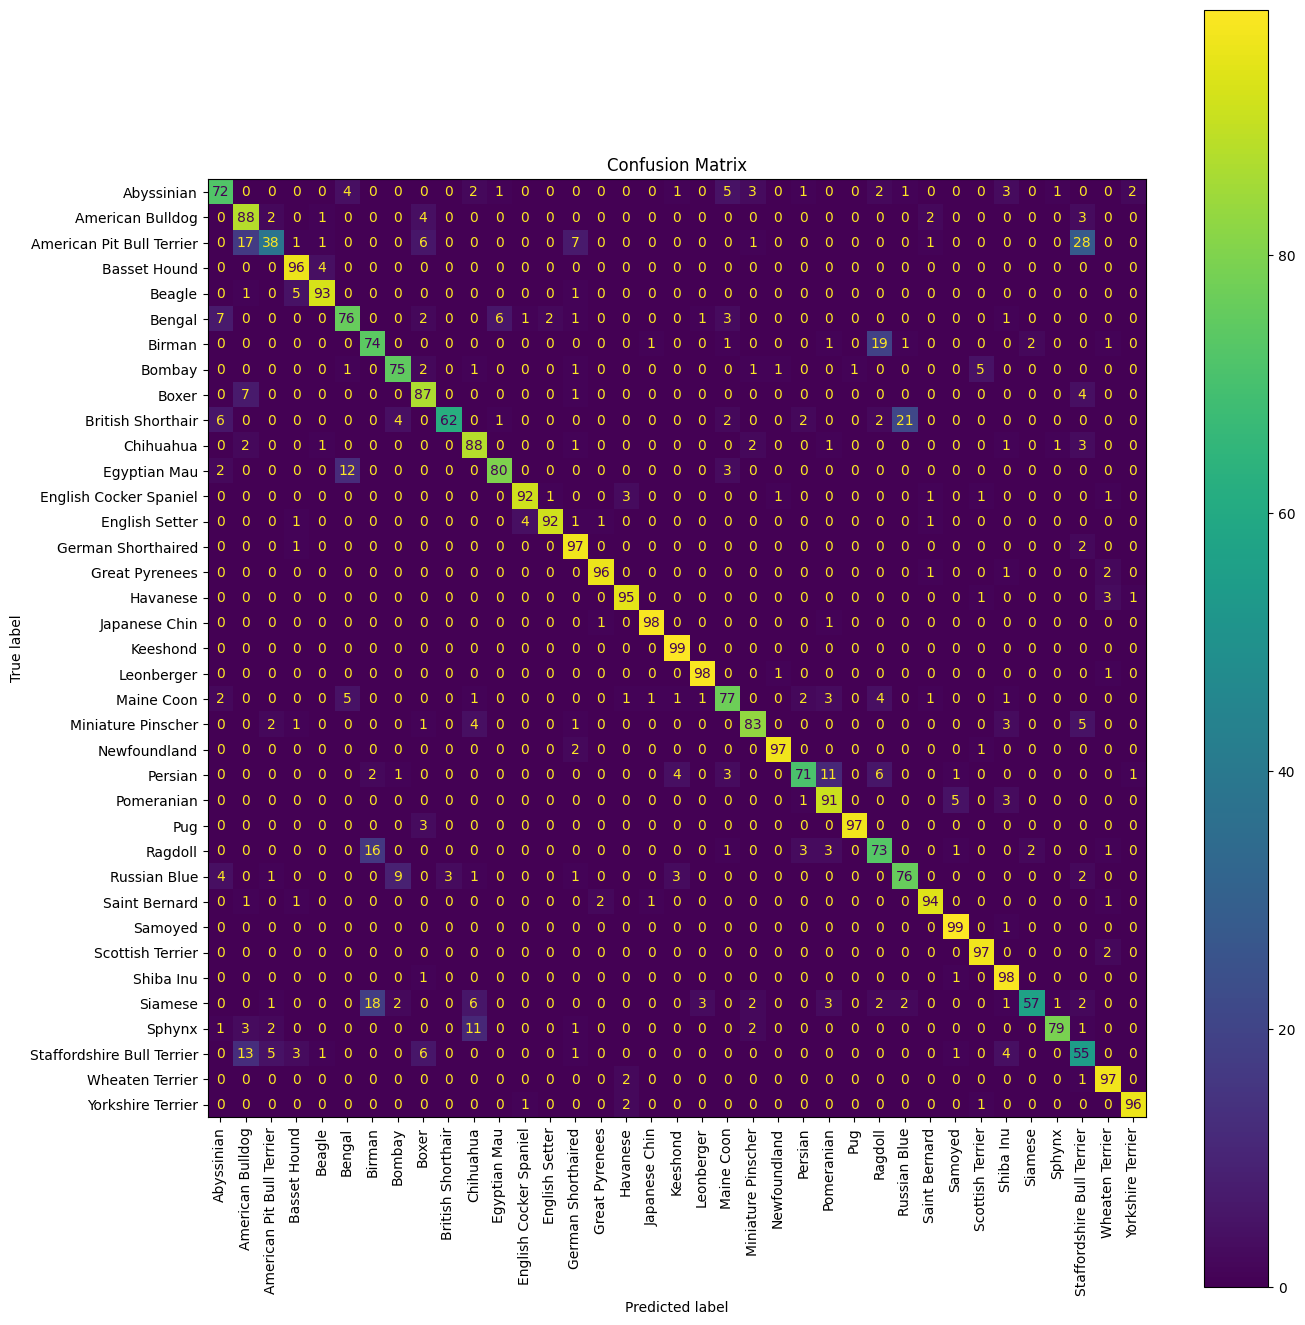

In [ ]:
def compute_class_weights(dataset):
    class_counts = defaultdict(int)
    for idx in range(len(dataset)):
        # Two levels of Subset wrapping
        actual_idx = dataset.dataset.indices[dataset.indices[idx]]
        label = dataset.dataset.dataset._labels[actual_idx]
        class_counts[label] += 1

    total = sum(class_counts.values())
    weights = torch.zeros(37)
    for cls, count in class_counts.items():
        weights[cls] = total / (37 * count)

    return weights.to(device)

class_weights = compute_class_weights(imbalanced_dataset)
criterion_weighted = nn.CrossEntropyLoss(weight=class_weights)

run_tests(imbalanced_loader, val_loader, advanced_eval=True, class_names=class_names, cat_labels = cat_labels, weighted_criterion=criterion_weighted)